# Compare imagery spectra and NDVI with ground truth — reviewed version

This notebook is a cleaned and more reproducible replacement for
`compare_imagery_spectra_and_ndvi_to_ground_truth_renew.ipynb`.

## Main changes

- Removes duplicate and unused imports.
- Centralizes configuration, paths, wavelengths, and analysis parameters.
- Preserves the **source site** when loading spectrometer files. This is essential:
  panel IDs such as `grey` and `black` do not begin with `B` or `W`, so inferring site
  from `station_id` incorrectly assigns them.
- Validates raster CRS metadata without assuming that all rasters use one CRS.\n- Reprojects vector polygons to each raster's native CRS before masking.
- Uses safe NDVI division.
- Separates pixel-level data from station/panel summaries.
- Generalizes panel extraction to every site, round, and DLS mode.
- Adds **Spectral Angle Mapper (SAM)** comparisons between imagery and spectrometer
  measurements of the grey panel.
- Adds bootstrap confidence intervals and scale-sensitive diagnostics (RMSE, bias,
  and gain-adjusted RMSE).
- Produces ranked tables and diagnostic plots.

## Interpretation

Spectral angle measures spectral **shape**, not absolute brightness. Lower is better:

- `0°`: identical direction/shape
- small angle: similar shape
- large angle: stronger spectral-shape disagreement

Because a grey panel is nearly spectrally flat, SAM should be interpreted together
with RMSE and bias. An image may have a small angle but still be too bright or dark.

## 1. Imports and display settings

In [1]:
from __future__ import annotations

from contextlib import nullcontext
from pathlib import Path
import datetime as dt
import os
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from pyproj import CRS
from IPython.display import display
from rasterio.mask import mask
from shapely.geometry import mapping

import hatfield_funcs as hf

PROJECT_ROOT = Path("../..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from biofilm_spectra.processing.micasense import (
    MICASENSE_10B_CENTER_WAVELENGTHS,
    resample_spectra_to_micasense_10B,
)
from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix
from my_extra_to_hatfield_funcs.io_funcs import read_df_from_parquet

plt.style.use("default")
%config InlineBackend.figure_format = "retina"
pd.set_option("display.max_columns", 120)

## 2. Configuration

### CRS note

The geometry coordinate values are assumed to already be in **EPSG:3157**.
The notebook replaces their CRS metadata with EPSG:3157 using
`set_crs(..., allow_override=True)`. It does **not** reproject or transform any
coordinates.

Some imagery files contain plain EPSG:3157, while others contain a compound CRS
consisting of the same EPSG:3157 horizontal CRS plus an unknown vertical CRS.
Only the horizontal component is compared for this 2-D masking workflow.


In [2]:
STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"
# Replace vector CRS metadata with this value; do not reproject coordinates.
GEOMETRY_CRS = "EPSG:3157"

ROUND_DATES = {
    1: "2026-05-04",
    2: "2026-05-18",
}

SITES = ("brunswick", "westham")
DLS_MODES = ("NoDLS", "DLS")
DLS_DISPLAY_LABELS = {
    "NoDLS": "No DLS correction",
    "DLS": "DLS correction",
}

# Source is an 11-band raster; omit its non-analysis band to obtain the
# ten MicaSense bands used below.
SOURCE_BANDS_11B_TO_10B = (1, 2, 3, 4, 6, 7, 8, 9, 10, 11)
BANDS_NM = tuple(int(x) for x in MICASENSE_10B_CENTER_WAVELENGTHS)

if len(SOURCE_BANDS_11B_TO_10B) != len(BANDS_NM):
    raise ValueError("Raster band indexes and MicaSense wavelengths do not match.")

STATION_POLYGONS = Path(
    "data/raw_clean/gnss/biofilm_2x2m_and_3x3m_quadrat_polygons.geojson"
)
SPECTRA_FOLDER = Path("data/processed/spectra")
PANEL_POLYGONS = {
    "westham": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_westham_v2.geojson"
    ),
    "brunswick": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_brunswick_v2.geojson"
    ),
}

ALL_TOUCHED = False
BOOTSTRAP_ITERATIONS = 2_000
RANDOM_SEED = 42

In [3]:
def to_vsiaz(path: str | Path) -> str:
    relative = str(path).replace("\\", "/").lstrip("/")
    return f"/vsiaz/{CONTAINER_NAME}/{relative}"


def configure_azure() -> None:
    if os.getenv("GA_STORAGE_ACCOUNT_NAME") is None:
        raise EnvironmentError(
            "GA_STORAGE_ACCOUNT_NAME is not set. Run this notebook in the "
            "configured GeoAnalytics environment."
        )

    hf.config.configure_azure()
    hf.config.configure_data_root_path(CONTAINER_NAME)

    os.environ.setdefault("AZURE_STORAGE_ACCOUNT", STORAGE_ACCOUNT_NAME)
    os.environ.setdefault("GDAL_AZURE_USE_MSI", "YES")
    os.environ.setdefault("GDAL_CACHEMAX", "512")


configure_azure()

## 3. Build and validate the imagery catalog

Raster CRS metadata is normalized to its projected horizontal component.
A compound CRS containing EPSG:3157 plus an unknown vertical CRS is therefore
treated as horizontally equivalent to plain EPSG:3157. No raster or vector
coordinates are transformed.

In [4]:
def horizontal_crs(crs) -> CRS:
    """Extract the projected horizontal component from a simple or compound CRS."""
    parsed = CRS.from_user_input(crs)

    if parsed.is_compound:
        projected = [
            component
            for component in parsed.sub_crs_list
            if component.is_projected
        ]
        if not projected:
            raise ValueError(
                f"Compound CRS has no projected horizontal component: {parsed}"
            )
        return projected[0]

    return parsed


def horizontal_crs_string(crs) -> str:
    """Return a compact normalized identifier for the horizontal CRS."""
    horizontal = horizontal_crs(crs)
    epsg = horizontal.to_epsg()
    return f"EPSG:{epsg}" if epsg is not None else horizontal.to_wkt()


def build_imagery_catalog() -> pd.DataFrame:
    records = []

    for round_number, date_string in ROUND_DATES.items():
        date = dt.datetime.strptime(date_string, "%Y-%m-%d")
        date_text = date.strftime("%Y%m%d")
        folder = f"airborne_data_{date_text}_v2_COG"

        for site in SITES:
            for dls_mode in DLS_MODES:
                relative_path = (
                    f"{folder}/"
                    f"RTB2_10Band_{site.capitalize()}_"
                    f"{date_text}_{dls_mode}_v2.tif"
                )
                records.append(
                    {
                        "site": site,
                        "round": round_number,
                        "date": pd.Timestamp(date),
                        "dls_mode": dls_mode,
                        "container_path": relative_path,
                        "raster_path": to_vsiaz(relative_path),
                    }
                )

    return (
        pd.DataFrame(records)
        .set_index(["site", "round", "dls_mode"])
        .sort_index()
    )


def validate_raster(path: str, band_indexes) -> dict:
    """Validate bands and normalize the raster's horizontal CRS."""
    with rasterio.open(path) as src:
        if src.crs is None:
            raise ValueError(f"Raster has no CRS: {path}")

        if max(band_indexes) > src.count:
            raise ValueError(
                f"{path} has {src.count} bands, but band {max(band_indexes)} "
                "was requested."
            )

        return {
            "source_crs": src.crs.to_string(),
            "horizontal_crs": horizontal_crs_string(src.crs),
            "count": src.count,
            "width": src.width,
            "height": src.height,
            "dtype": src.dtypes[0],
        }


imagery_catalog = build_imagery_catalog()
display(imagery_catalog)

raster_validation = []
for idx, row in imagery_catalog.iterrows():
    metadata = validate_raster(
        row["raster_path"],
        band_indexes=SOURCE_BANDS_11B_TO_10B,
    )
    raster_validation.append(
        {**dict(zip(imagery_catalog.index.names, idx)), **metadata}
    )

raster_validation = pd.DataFrame(raster_validation)

display(
    raster_validation[
        [
            "site",
            "round",
            "dls_mode",
            "horizontal_crs",
            "count",
            "width",
            "height",
            "dtype",
        ]
    ]
)

unexpected_crs = raster_validation.loc[
    raster_validation["horizontal_crs"].str.upper()
    != GEOMETRY_CRS.upper()
]

if not unexpected_crs.empty:
    raise ValueError(
        f"Expected horizontal CRS {GEOMETRY_CRS}, but found:\n"
        + unexpected_crs[
            ["site", "round", "dls_mode", "horizontal_crs"]
        ].to_string(index=False)
    )

print("Horizontal imagery CRS:", GEOMETRY_CRS)
print(
    "Compound CRS variants are accepted when their horizontal component "
    f"is {GEOMETRY_CRS}."
)


date  \
site      round dls_mode              
brunswick 1     DLS      2026-05-04   
                NoDLS    2026-05-04   
          2     DLS      2026-05-18   
                NoDLS    2026-05-18   
westham   1     DLS      2026-05-04   
                NoDLS    2026-05-04   
          2     DLS      2026-05-18   
                NoDLS    2026-05-18   

                                                             container_path  \
site      round dls_mode                                                      
brunswick 1     DLS       airborne_data_20260504_v2_COG/RTB2_10Band_Brun...   
                NoDLS     airborne_data_20260504_v2_COG/RTB2_10Band_Brun...   
          2     DLS       airborne_data_20260518_v2_COG/RTB2_10Band_Brun...   
                NoDLS     airborne_data_20260518_v2_COG/RTB2_10Band_Brun...   
westham   1     DLS       airborne_data_20260504_v2_COG/RTB2_10Band_West...   
                NoDLS     airborne_data_20260504_v2_COG/RTB2_10Band_West...   
          2     DLS       airborne_data_20260518_v2_COG/RTB2_10Band_West...   
                NoDLS     airborne_data_20260518_v2_COG/RTB2_10Band_West...   

                                                                raster_path  
site      round dls_mode                                                     
brunswick 1     DLS       /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
                NoDLS     /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
          2     DLS       /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
                NoDLS     /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
westham   1     DLS       /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
                NoDLS     /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
          2     DLS       /vsiaz/wesa-fup-restricted-027817p/airborne_da...  
                NoDLS     /vsiaz/wesa-fup-restricted-027817p/airborne_da...

,site,round,dls_mode,horizontal_crs,count,width,height,dtype
0,brunswick,1,DLS,EPSG:3157,11,22597,16490,float32
1,brunswick,1,NoDLS,EPSG:3157,11,22593,16498,float32
2,brunswick,2,DLS,EPSG:3157,11,23451,16978,float32
3,brunswick,2,NoDLS,EPSG:3157,11,23451,16966,float32
4,westham,1,DLS,EPSG:3157,11,16588,20093,float32
5,westham,1,NoDLS,EPSG:3157,11,16587,20092,float32
6,westham,2,DLS,EPSG:3157,11,16587,20092,float32
7,westham,2,NoDLS,EPSG:3157,11,16588,20093,float32


Horizontal imagery CRS: EPSG:3157
Compound CRS variants are accepted when their horizontal component is EPSG:3157.


### CRS handling

The imagery COGs are tagged **EPSG:3157** (`NAD83(CSRS) / UTM zone 10N`),
while the canonical vector geometry CRS used in this project is **EPSG:6339**
(`NAD83(2011) / UTM zone 10N`). The notebook no longer assumes these CRS
identifiers must be identical. Instead, each polygon is transformed into the
native raster CRS immediately before raster masking.

Do not simply relabel the raster from EPSG:3157 to EPSG:6339 unless independent
metadata confirms that its CRS tag is wrong.

## 4. Geometry loading and validation

Vector CRS metadata is replaced with EPSG:3157 using
`set_crs(..., allow_override=True)`. Coordinate values remain unchanged.

In [5]:
def validate_geometries(
    gdf: gpd.GeoDataFrame,
    label: str,
) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        warnings.warn(
            f"{label} has no source CRS metadata; assigning {GEOMETRY_CRS} "
            "without changing coordinates."
        )
    if gdf.geometry.isna().any():
        raise ValueError(f"{label} contains missing geometries.")

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        warnings.warn(
            f"{label}: repairing {invalid.sum()} invalid geometries with buffer(0)."
        )
        gdf = gdf.copy()
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    if (~gdf.geometry.is_valid).any():
        raise ValueError(f"{label} still contains invalid geometries after repair.")

    # Replace CRS metadata only. Coordinate values are unchanged.
    return gdf.set_crs(GEOMETRY_CRS, allow_override=True)

def parse_bool(series: pd.Series, field_name: str) -> pd.Series:
    mapping_bool = {
        "true": True,
        "false": False,
        "yes": True,
        "no": False,
        "1": True,
        "0": False,
    }
    result = (
        series.astype("string")
        .str.strip()
        .str.lower()
        .map(mapping_bool)
        .astype("boolean")
    )
    if result.isna().any():
        bad = series[result.isna()].unique().tolist()
        raise ValueError(f"Could not parse {field_name}: {bad}")
    return result

In [6]:
def load_station_polygons() -> gpd.GeoDataFrame:
    gdf = gpd.read_file(to_vsiaz(STATION_POLYGONS))
    gdf = validate_geometries(gdf, "station polygons").copy()

    gdf["station_id"] = gdf["station_name"].astype("string").str.strip()
    gdf["round"] = pd.to_numeric(gdf["round"], errors="raise").astype("int64")
    gdf["is_3x3m"] = parse_bool(gdf["is_3x3m"], "is_3x3m")

    prefix = gdf["station_id"].str[0]
    site_map = {"B": "brunswick", "W": "westham"}
    gdf["site"] = prefix.map(site_map)
    if gdf["site"].isna().any():
        bad = gdf.loc[gdf["site"].isna(), "station_id"].unique().tolist()
        raise ValueError(f"Unknown station prefixes: {bad}")

    # Retain only the 2 x 2 m polygons used in the original comparison.
    gdf = gdf.loc[~gdf["is_3x3m"]].copy()

    duplicate = gdf.duplicated(["site", "round", "station_id"], keep=False)
    if duplicate.any():
        raise ValueError(
            "Duplicate 2 x 2 m station polygons:\n"
            + gdf.loc[duplicate, ["site", "round", "station_id"]].to_string(index=False)
        )

    return gdf.set_index(["site", "round", "station_id"]).sort_index()


stations = load_station_polygons()
print(f"2 x 2 m station polygons: {len(stations)}")
display(stations.head())

2 x 2 m station polygons: 120


station_name  is_3x3m extended_protocol  side_m  \
site      round station_id                                                   
brunswick 1     B1                   B1    False                No     2.0   
                B10                 B10    False                No     2.0   
                B11                 B11    False                No     2.0   
                B12                 B12    False                No     2.0   
                B13                 B13    False                No     2.0   

                                                                     geometry  
site      round station_id                                                     
brunswick 1     B1          POLYGON ((488833.82 5434224.912, 488835.82 543...  
                B10         POLYGON ((488875.848 5433865.401, 488877.848 5...  
                B11         POLYGON ((489056.793 5433627.776, 489058.793 5...  
                B12         POLYGON ((488897.659 5433305.857, 488899.659 5...  
                B13         POLYGON ((488555.946 5433166.387, 488557.946 5...

In [7]:
def load_panel_polygons() -> gpd.GeoDataFrame:
    frames = []

    for site, path in PANEL_POLYGONS.items():
        gdf = gpd.read_file(to_vsiaz(path))
        gdf = validate_geometries(gdf, f"{site} panel polygons").copy()
        gdf["site"] = site

        if "description" not in gdf.columns:
            if "feature_id" not in gdf.columns:
                raise ValueError(
                    f"{site}: neither 'description' nor 'feature_id' is available."
                )
            gdf["description"] = gdf["feature_id"]

        gdf = gdf.loc[
            gdf["description"].astype("string").str.contains(
                "panel", case=False, na=False
            )
        ].copy()

        gdf["round"] = pd.to_numeric(gdf["day"], errors="coerce").map({4: 1, 18: 2})
        if gdf["round"].isna().any():
            bad_days = gdf.loc[gdf["round"].isna(), "day"].unique().tolist()
            raise ValueError(f"{site}: unrecognized panel days: {bad_days}")

        # First word is expected to identify grey/black/etc.
        gdf["panel_id"] = (
            gdf["description"]
            .astype("string")
            .str.strip()
            .str.split()
            .str[0]
            .str.lower()
        )
        frames.append(gdf[["site", "round", "panel_id", "geometry"]])

    panels = pd.concat(frames, ignore_index=True)
    panels = gpd.GeoDataFrame(panels, geometry="geometry", crs=GEOMETRY_CRS)

    duplicate = panels.duplicated(["site", "round", "panel_id"], keep=False)
    if duplicate.any():
        warnings.warn(
            "Multiple polygons found for a site/round/panel. They will be treated "
            "as separate extraction regions and combined at the pixel level."
        )

    return panels.sort_values(["site", "round", "panel_id"]).reset_index(drop=True)


panels = load_panel_polygons()
display(panels)

/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,site,round,panel_id,geometry
0,westham,1,grey,"MULTIPOLYGON (((486920.213 5436983.158, 486921..."
1,westham,2,black,"MULTIPOLYGON (((486919.534 5436989.418, 486920..."
2,westham,2,grey,"MULTIPOLYGON (((486920.125 5436983.52, 486921...."


## 5. Raster extraction helpers

In [8]:
def extract_spectra_in_polygon(
    raster,
    geometry,
    *,
    band_indexes=SOURCE_BANDS_11B_TO_10B,
    wavelengths_nm=BANDS_NM,
    all_touched: bool = ALL_TOUCHED,
) -> pd.DataFrame:
    """Return one valid pixel spectrum per row without reprojecting geometry.

    The geometry coordinate values are used exactly as stored. Its CRS metadata
    has already been replaced with EPSG:3157.
    """
    band_indexes = tuple(band_indexes)
    wavelengths_nm = tuple(wavelengths_nm)

    if len(band_indexes) != len(wavelengths_nm):
        raise ValueError("Band indexes and wavelength labels must have equal length.")

    context = (
        rasterio.open(raster)
        if isinstance(raster, (str, Path))
        else nullcontext(raster)
    )

    with context as src:
        if src.crs is None:
            raise ValueError(
                f"Raster has no CRS: {getattr(src, 'name', '<open dataset>')}"
            )

        raster_horizontal_crs = horizontal_crs_string(src.crs)
        if raster_horizontal_crs.upper() != GEOMETRY_CRS.upper():
            raise ValueError(
                f"Raster horizontal CRS {raster_horizontal_crs} differs from "
                f"assigned geometry CRS {GEOMETRY_CRS}: "
                f"{getattr(src, 'name', '<open dataset>')}"
            )

        # No transform or reprojection occurs here.
        data, _ = mask(
            src,
            [mapping(geometry)],
            indexes=band_indexes,
            crop=True,
            filled=False,
            all_touched=all_touched,
        )

    mask_array = np.ma.getmaskarray(data)
    valid = (~mask_array.any(axis=0)) & np.isfinite(data.data).all(axis=0)

    if not valid.any():
        return pd.DataFrame(columns=wavelengths_nm, dtype="float64")

    spectra = data.data[:, valid].T.astype("float64")
    result = pd.DataFrame(spectra, columns=wavelengths_nm)
    result.index.name = "pixel_id"
    return result

def safe_normalized_difference(
    numerator_a: pd.Series,
    numerator_b: pd.Series,
) -> pd.Series:
    denominator = numerator_a + numerator_b
    return (numerator_a - numerator_b).div(
        denominator.where(~np.isclose(denominator, 0.0))
    )

## 6. Extract imagery spectra for station quadrats

In [9]:
def extract_station_imagery_spectra(
    catalog: pd.DataFrame,
    station_polygons: gpd.GeoDataFrame,
) -> pd.DataFrame:
    frames = []

    for (site, round_number, dls_mode), raster_row in catalog.iterrows():
        try:
            subset = station_polygons.xs(
                (site, round_number),
                level=("site", "round"),
                drop_level=False,
            )
        except KeyError:
            warnings.warn(f"No station polygons for {site}, round {round_number}.")
            continue

        print(
            f"Extracting stations: {site} | round {round_number} | "
            f"{dls_mode} | {len(subset)} stations"
        )

        # Open each remote COG once. Reproject this vector subset to the
        # raster's native CRS once, then reuse the dataset for all polygons.
        with rasterio.open(raster_row["raster_path"]) as src:
            subset_in_raster_crs = subset.to_crs(src.crs)

            for index, station in subset_in_raster_crs.iterrows():
                station_id = index[2]
                spectra = extract_spectra_in_polygon(
                    src,
                    station.geometry,
                )
                if spectra.empty:
                    warnings.warn(
                        f"No valid pixels: {site}, round {round_number}, "
                        f"{dls_mode}, {station_id}"
                    )
                    continue

                spectra = spectra.reset_index()
                spectra.insert(0, "station_id", station_id)
                spectra.insert(0, "dls_mode", dls_mode)
                spectra.insert(0, "round", round_number)
                spectra.insert(0, "site", site)
                frames.append(spectra)

    if not frames:
        raise RuntimeError("No station imagery spectra were extracted.")

    result = pd.concat(frames, ignore_index=True)
    result["NDVI740"] = safe_normalized_difference(result[740], result[668])
    return result.set_index(
        ["site", "round", "dls_mode", "station_id", "pixel_id"]
    ).sort_index()


station_imagery_pixels = extract_station_imagery_spectra(
    imagery_catalog,
    stations,
)
print(station_imagery_pixels.shape)
display(station_imagery_pixels.head())

Extracting stations: brunswick | round 1 | DLS | 30 stations
Extracting stations: brunswick | round 1 | NoDLS | 30 stations
Extracting stations: brunswick | round 2 | DLS | 30 stations
Extracting stations: brunswick | round 2 | NoDLS | 30 stations
Extracting stations: westham | round 1 | DLS | 30 stations
Extracting stations: westham | round 1 | NoDLS | 30 stations
Extracting stations: westham | round 2 | DLS | 30 stations
Extracting stations: westham | round 2 | NoDLS | 30 stations
(10812, 11)


444       475       531  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     DLS      B1         0         0.018987  0.019331  0.023057   
                                    1         0.018657  0.018923  0.022857   
                                    2         0.018045  0.018466  0.021975   
                                    3         0.017865  0.018615  0.021556   
                                    4         0.018131  0.018587  0.021687   

                                                   560       650       668  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     DLS      B1         0         0.024146  0.023884  0.020690   
                                    1         0.024167  0.023543  0.020321   
                                    2         0.023770  0.022476  0.019617   
                                    3         0.023213  0.022062  0.019275   
                                    4         0.022837  0.022189  0.019528   

                                                   705       717       740  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     DLS      B1         0         0.025899  0.026981  0.026511   
                                    1         0.025710  0.026250  0.026670   
                                    2         0.025097  0.025809  0.025452   
                                    3         0.024521  0.025418  0.024839   
                                    4         0.024499  0.025402  0.024928   

                                                   842   NDVI740  
site      round dls_mode station_id pixel_id                      
brunswick 1     DLS      B1         0         0.029587  0.123332  
                                    1         0.029977  0.135116  
                                    2         0.028921  0.129466  
                                    3         0.028416  0.126133  
                                    4         0.028567  0.121470

In [10]:
station_imagery_stats = (
    station_imagery_pixels
    .groupby(level=["site", "round", "dls_mode", "station_id"])
    .agg(["mean", "std", "count"])
)
display(station_imagery_stats.head())

444                       475  \
                                         mean       std count      mean   
site      round dls_mode station_id                                       
brunswick 1     DLS      B1          0.016985  0.001458    42  0.017516   
                         B10         0.016650  0.001132    49  0.017125   
                         B11         0.018238  0.000745    49  0.018384   
                         B12         0.019162  0.001643    42  0.019251   
                         B13         0.014660  0.001194    42  0.015025   

                                                          531                  \
                                          std count      mean       std count   
site      round dls_mode station_id                                             
brunswick 1     DLS      B1          0.001468    42  0.021028  0.001378    42   
                         B10         0.001132    49  0.021316  0.001276    49   
                         B11         0.000818    49  0.021655  0.001034    49   
                         B12         0.001728    42  0.021945  0.001550    42   
                         B13         0.001219    42  0.017327  0.001132    42   

                                          560                       650  \
                                         mean       std count      mean   
site      round dls_mode station_id                                       
brunswick 1     DLS      B1          0.022332  0.001307    42  0.021839   
                         B10         0.022701  0.001349    49  0.022299   
                         B11         0.023106  0.001193    49  0.022416   
                         B12         0.022586  0.001427    42  0.022390   
                         B13         0.018132  0.001062    42  0.018027   

                                                          668                  \
                                          std count      mean       std count   
site      round dls_mode station_id                                             
brunswick 1     DLS      B1          0.001152    42  0.018987  0.001018    42   
                         B10         0.001346    49  0.019090  0.000894    49   
                         B11         0.001262    49  0.019270  0.000974    49   
                         B12         0.001277    42  0.020167  0.001192    42   
                         B13         0.001014    42  0.016361  0.001034    42   

                                          705                       717  \
                                         mean       std count      mean   
site      round dls_mode station_id                                       
brunswick 1     DLS      B1          0.024162  0.001285    42  0.025021   
                         B10         0.024525  0.001552    49  0.025302   
                         B11         0.024378  0.001131    49  0.025278   
                         B12         0.023923  0.001393    42  0.023920   
                         B13         0.019539  0.001196    42  0.019599   

                                                          740                  \
                                          std count      mean       std count   
site      round dls_mode station_id                                             
brunswick 1     DLS      B1          0.001374    42  0.024821  0.001343    42   
                         B10         0.001882    49  0.024408  0.001752    49   
                         B11         0.001588    49  0.025039  0.001615    49   
                         B12         0.001592    42  0.024022  0.001509    42   
                         B13         0.001268    42  0.018707  0.001606    42   

                                          842                   NDVI740  \
                                         mean       std count      mean   
site      round dls_mode station_id                                       
brunswick 1     DLS      B1          0.027908  0.001365    42  0.13

## 7. Load and resample spectrometer ground truth

**Important correction:** `site` is added to each source parquet before the files
are concatenated. The original notebook inferred site from `station_id`; that works
for IDs such as `B12` and `W12`, but incorrectly assigns non-prefixed IDs such as
`grey` and `black`.

In [11]:
def load_ground_truth_scans() -> pd.DataFrame:
    frames = []

    for site in SITES:
        path = SPECTRA_FOLDER / (
            f"{site}_reflectance_common_wavelengths_scans.parquet"
        )
        site_df = read_df_from_parquet(path).copy()
        site_df["site"] = site
        frames.append(site_df)

    result = pd.concat(frames, ignore_index=True)

    required = {
        "site", "station_id", "round", "sample_type", "scan_id", "pair_id"
    }
    missing = required.difference(result.columns)
    if missing:
        raise ValueError(f"Ground-truth table is missing columns: {sorted(missing)}")

    result["station_id"] = result["station_id"].astype("string").str.strip()
    result["round"] = pd.to_numeric(result["round"], errors="raise").astype("int64")
    return result


ground_truth_scans_raw = load_ground_truth_scans()
display(
    ground_truth_scans_raw[
        ["site", "station_id", "round", "sample_type", "scan_id", "pair_id"]
    ].head()
)

,site,station_id,round,sample_type,scan_id,pair_id
0,brunswick,B9,1,R,0,0
1,brunswick,B9,1,R,1,0
2,brunswick,B9,1,R,2,1
3,brunswick,B9,1,R,3,1
4,brunswick,B9,1,R,4,2


In [12]:
SCAN_METADATA = [
    "site",
    "station_id",
    "round",
    "sample_type",
    "scan_id",
    "pair_id",
]

ground_truth_matrix = to_spectral_matrix(
    ground_truth_scans_raw,
    scan_cols=SCAN_METADATA,
)

sample_mask = (
    ground_truth_matrix.columns
    .get_level_values("sample_type")
    .isin(["R", "O"])
)
ground_truth_matrix = ground_truth_matrix.loc[:, sample_mask]

ground_truth_10b_matrix = resample_spectra_to_micasense_10B(
    ground_truth_matrix
)

ground_truth_10b = (
    ground_truth_10b_matrix.T
    .reset_index()
    .rename_axis(columns=None)
)

# Normalize wavelength labels to integers so they match the imagery table.
rename_bands = {
    column: int(column)
    for column in ground_truth_10b.columns
    if isinstance(column, (int, float, np.integer, np.floating))
}
ground_truth_10b = ground_truth_10b.rename(columns=rename_bands)

missing_bands = set(BANDS_NM).difference(ground_truth_10b.columns)
if missing_bands:
    raise ValueError(
        f"Resampled ground truth is missing MicaSense bands: {sorted(missing_bands)}"
    )

ground_truth_10b["NDVI740"] = safe_normalized_difference(
    ground_truth_10b[740],
    ground_truth_10b[668],
)

display(ground_truth_10b.head())

,site,station_id,round,sample_type,scan_id,pair_id,444,475,531,560,650,668,705,717,740,842,NDVI740
0,brunswick,B9,1,R,0,0,0.041942,0.050375,0.073353,0.086688,0.096481,0.085349,0.107595,0.110575,0.113878,0.122656,0.143201
1,brunswick,B9,1,R,1,0,0.043118,0.051341,0.074149,0.087458,0.097266,0.085999,0.108424,0.111394,0.114607,0.123336,0.142610
2,brunswick,B9,1,R,2,1,0.045860,0.054453,0.077763,0.090667,0.100088,0.089272,0.110321,0.113060,0.116366,0.124574,0.131753
3,brunswick,B9,1,R,3,1,0.046504,0.055122,0.079181,0.092964,0.102024,0.089631,0.113588,0.116649,0.120017,0.128534,0.144937
4,brunswick,B9,1,R,4,2,0.039972,0.049177,0.072757,0.085914,0.097663,0.089010,0.108493,0.111174,0.114366,0.123093,0.124673


## 8. Station-level spectrum and NDVI comparison

In [13]:
SPECTRAL_COLUMNS = list(BANDS_NM)

station_image_means = (
    station_imagery_pixels[SPECTRAL_COLUMNS + ["NDVI740"]]
    .groupby(level=["site", "round", "dls_mode", "station_id"])
    .mean()
    .reset_index()
)

station_ground_means = (
    ground_truth_10b.loc[ground_truth_10b["sample_type"].eq("R")]
    .groupby(["site", "round", "station_id"], as_index=False)[
        SPECTRAL_COLUMNS + ["NDVI740"]
    ]
    .mean()
)

station_comparison = station_image_means.merge(
    station_ground_means,
    on=["site", "round", "station_id"],
    how="inner",
    suffixes=("_image", "_ground"),
    validate="many_to_one",
)

print(f"Matched station comparisons: {len(station_comparison)}")
display(station_comparison.head())

Matched station comparisons: 240


,site,round,dls_mode,station_id,444_image,475_image,531_image,560_image,650_image,668_image,705_image,717_image,740_image,842_image,NDVI740_image,444_ground,475_ground,531_ground,560_ground,650_ground,668_ground,705_ground,717_ground,740_ground,842_ground,NDVI740_ground
0,brunswick,1,DLS,B1,0.016985,0.017516,0.021028,0.022332,0.021839,0.018987,0.024162,0.025021,0.024821,0.027908,0.133157,0.038055,0.045220,0.064972,0.075927,0.083512,0.075327,0.091339,0.093436,0.095960,0.102775,0.120326
1,brunswick,1,DLS,B10,0.016650,0.017125,0.021316,0.022701,0.022299,0.019090,0.024525,0.025302,0.024408,0.026377,0.121489,0.047268,0.054339,0.077089,0.091416,0.097695,0.082605,0.111692,0.115371,0.118709,0.124086,0.179997
2,brunswick,1,DLS,B11,0.018238,0.018384,0.021655,0.023106,0.022416,0.019270,0.024378,0.025278,0.025039,0.026686,0.129720,0.035086,0.041564,0.061745,0.074525,0.083154,0.074510,0.091615,0.094074,0.096963,0.103180,0.131063
3,brunswick,1,DLS,B12,0.019162,0.019251,0.021945,0.022586,0.022390,0.020167,0.023923,0.023920,0.024022,0.025210,0.087101,0.053681,0.059509,0.074701,0.082963,0.087183,0.080364,0.093106,0.094543,0.096316,0.099562,0.091048
4,brunswick,1,DLS,B13,0.014660,0.015025,0.017327,0.018132,0.018027,0.016361,0.019539,0.019599,0.018707,0.019829,0.066034,0.045095,0.049963,0.061745,0.068697,0.072004,0.067666,0.077570,0.079191,0.080960,0.084655,0.088672


In [14]:
def spectral_angle_degrees(
    observed,
    reference,
    *,
    min_bands: int = 3,
) -> float:
    """Spectral angle in degrees; lower values indicate better shape agreement."""
    observed = np.asarray(observed, dtype="float64")
    reference = np.asarray(reference, dtype="float64")
    valid = np.isfinite(observed) & np.isfinite(reference)

    if valid.sum() < min_bands:
        return np.nan

    observed = observed[valid]
    reference = reference[valid]

    denominator = np.linalg.norm(observed) * np.linalg.norm(reference)
    if denominator <= 0:
        return np.nan

    cosine = np.clip(np.dot(observed, reference) / denominator, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))


def comparison_metrics(observed, reference) -> pd.Series:
    observed = np.asarray(observed, dtype="float64")
    reference = np.asarray(reference, dtype="float64")
    valid = np.isfinite(observed) & np.isfinite(reference)

    if valid.sum() < 3:
        return pd.Series(
            {
                "spectral_angle_deg": np.nan,
                "rmse": np.nan,
                "nrmse_ground_mean": np.nan,
                "mean_bias": np.nan,
                "gain_to_ground": np.nan,
                "gain_adjusted_rmse": np.nan,
            }
        )

    observed = observed[valid]
    reference = reference[valid]
    residual = observed - reference

    ground_mean = np.mean(reference)
    observed_energy = np.dot(observed, observed)
    gain = (
        np.dot(observed, reference) / observed_energy
        if observed_energy > 0
        else np.nan
    )

    return pd.Series(
        {
            "spectral_angle_deg": spectral_angle_degrees(observed, reference),
            "rmse": np.sqrt(np.mean(residual**2)),
            "nrmse_ground_mean": (
                np.sqrt(np.mean(residual**2)) / abs(ground_mean)
                if not np.isclose(ground_mean, 0.0)
                else np.nan
            ),
            "mean_bias": np.mean(residual),
            "gain_to_ground": gain,
            "gain_adjusted_rmse": (
                np.sqrt(np.mean((gain * observed - reference) ** 2))
                if np.isfinite(gain)
                else np.nan
            ),
        }
    )

In [15]:
station_metric_rows = []

for _, row in station_comparison.iterrows():
    observed = row[[f"{band}_image" for band in SPECTRAL_COLUMNS]].to_numpy()
    reference = row[[f"{band}_ground" for band in SPECTRAL_COLUMNS]].to_numpy()
    metrics = comparison_metrics(observed, reference).to_dict()

    station_metric_rows.append(
        {
            "site": row["site"],
            "round": row["round"],
            "dls_mode": row["dls_mode"],
            "station_id": row["station_id"],
            "ndvi_image": row["NDVI740_image"],
            "ndvi_ground": row["NDVI740_ground"],
            "ndvi_error": row["NDVI740_image"] - row["NDVI740_ground"],
            **metrics,
        }
    )

station_metrics = pd.DataFrame(station_metric_rows)

station_imagery_summary = (
    station_metrics
    .groupby(["site", "round", "dls_mode"], as_index=False)
    .agg(
        n_stations=("station_id", "nunique"),
        median_spectral_angle_deg=("spectral_angle_deg", "median"),
        mean_spectral_angle_deg=("spectral_angle_deg", "mean"),
        median_rmse=("rmse", "median"),
        ndvi_mae=("ndvi_error", lambda x: np.nanmean(np.abs(x))),
        ndvi_bias=("ndvi_error", "mean"),
    )
    .sort_values(
        ["median_spectral_angle_deg", "median_rmse"],
        ascending=True,
    )
)

display(station_imagery_summary)

,site,round,dls_mode,n_stations,median_spectral_angle_deg,mean_spectral_angle_deg,median_rmse,ndvi_mae,ndvi_bias
3,brunswick,2,NoDLS,30,1.659104,2.024962,0.052957,0.019100,-0.005610
2,brunswick,2,DLS,30,1.686674,2.095943,0.012163,0.018580,-0.002604
5,westham,1,NoDLS,30,2.178107,2.568595,0.026263,0.028087,-0.020924
6,westham,2,DLS,30,2.371503,2.491071,0.008315,0.037244,-0.030134
7,westham,2,NoDLS,30,2.436594,2.494555,0.050094,0.039177,-0.032785
1,brunswick,1,NoDLS,30,2.824342,3.255541,0.039019,0.027731,-0.004924
4,westham,1,DLS,30,3.252408,3.409563,0.048337,0.026370,-0.017345
0,brunswick,1,DLS,30,5.289640,5.847970,0.060818,0.027201,0.002437


## 9. Grey-panel imagery extraction and spatial-scope correction

The grey panel is physically located in the **Westham imagery footprint**.
Therefore, pixels are extracted only from the Westham rasters.

Two comparison scopes are then produced from those same Westham pixels:

1. **Westham native scope** — unchanged Westham imagery, compared with the
   Westham grey-panel spectrometer for the corresponding round.
2. **Westham → Brunswick corrected scope** — the date-, DLS-mode-, and
   band-specific affine spatial coefficients are applied to the Westham pixels,
   and the corrected spectra are compared with the Brunswick grey-panel
   spectrometer for the corresponding round.

The correction convention, taken from the bidirectional spatial-coefficient
workflow, is:

\[
R_{Brunswick} = gain_{W\rightarrow B} R_{Westham} + offset_{W\rightarrow B}.
\]

No pixels are extracted from Brunswick imagery for this grey-panel test.

In [16]:
SPATIAL_COEFFICIENT_RELATIVE_PATH = Path(
    "data/processed/imagery/radiometry_eval/"
    "bidirectional_spatial_coefficients/"
    "all_bidirectional_spatial_coefficients.parquet"
)

WESTHAM_TO_BRUNSWICK_DIRECTION = "westham_to_brunswick"

BAND_NAME_BY_WAVELENGTH = {
    444: "B1",
    475: "B2",
    531: "B3",
    560: "B4",
    650: "B5",
    668: "B6",
    705: "B7",
    717: "B8",
    740: "B9",
    842: "B10",
}

SCOPE_LABELS = {
    "westham_native": "Westham imagery — native Westham scope",
    "brunswick_corrected": (
        "Westham imagery — corrected to Brunswick scope"
    ),
}


def load_spatial_coefficients() -> pd.DataFrame:
    local_candidates = [
        PROJECT_ROOT / SPATIAL_COEFFICIENT_RELATIVE_PATH,
        SPATIAL_COEFFICIENT_RELATIVE_PATH,
    ]

    coefficients = None
    for candidate in local_candidates:
        if candidate.exists():
            coefficients = pd.read_parquet(candidate)
            print("Loaded spatial coefficients:", candidate.resolve())
            break

    if coefficients is None:
        # Fall back to the project helper, which may resolve the path through
        # the configured data root.
        coefficients = read_df_from_parquet(
            SPATIAL_COEFFICIENT_RELATIVE_PATH
        )
        print(
            "Loaded spatial coefficients through configured data root:",
            SPATIAL_COEFFICIENT_RELATIVE_PATH,
        )

    required = {
        "flight_date",
        "dls_mode",
        "direction",
        "band_name",
        "wavelength_nm",
        "is_pan",
        "gain",
        "offset",
    }
    missing = required.difference(coefficients.columns)
    if missing:
        raise ValueError(
            f"Spatial coefficient table is missing columns: {sorted(missing)}"
        )

    coefficients = coefficients.copy()
    coefficients["flight_date"] = (
        pd.to_datetime(coefficients["flight_date"])
        .dt.strftime("%Y-%m-%d")
    )

    coefficients = coefficients.loc[
        coefficients["direction"].eq(WESTHAM_TO_BRUNSWICK_DIRECTION)
        & coefficients["band_name"].ne("PAN")
    ].copy()

    coefficients["wavelength_nm"] = pd.to_numeric(
        coefficients["wavelength_nm"],
        errors="raise",
    ).astype(int)

    duplicate_keys = [
        "flight_date",
        "dls_mode",
        "direction",
        "wavelength_nm",
    ]
    duplicate = coefficients.duplicated(duplicate_keys, keep=False)
    if duplicate.any():
        raise ValueError(
            "Duplicate Westham-to-Brunswick coefficient keys:\n"
            + coefficients.loc[
                duplicate,
                duplicate_keys + ["gain", "offset"],
            ].to_string(index=False)
        )

    expected_keys = {
        (date, dls_mode, wavelength)
        for date in ROUND_DATES.values()
        for dls_mode in DLS_MODES
        for wavelength in SPECTRAL_COLUMNS
    }
    actual_keys = set(
        map(
            tuple,
            coefficients[
                ["flight_date", "dls_mode", "wavelength_nm"]
            ].to_numpy(),
        )
    )
    missing_keys = expected_keys.difference(actual_keys)
    if missing_keys:
        raise ValueError(
            "Missing Westham-to-Brunswick spatial coefficients: "
            f"{sorted(missing_keys)}"
        )

    return coefficients.sort_values(
        ["flight_date", "dls_mode", "wavelength_nm"]
    ).reset_index(drop=True)


spatial_coefficients_westham_to_brunswick = load_spatial_coefficients()

display(
    spatial_coefficients_westham_to_brunswick[
        [
            "flight_date",
            "dls_mode",
            "direction",
            "band_name",
            "wavelength_nm",
            "gain",
            "offset",
            "r2",
            "rmse",
        ]
    ]
)

Loaded spatial coefficients: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients/all_bidirectional_spatial_coefficients.parquet


,flight_date,dls_mode,direction,band_name,wavelength_nm,gain,offset,r2,rmse
0,2026-05-04,DLS,westham_to_brunswick,B1,444,0.441664,0.003443,0.932240,0.000564
1,2026-05-04,DLS,westham_to_brunswick,B2,475,0.403932,0.004160,0.918943,0.000531
2,2026-05-04,DLS,westham_to_brunswick,B3,531,0.351953,0.006341,0.845675,0.000663
3,2026-05-04,DLS,westham_to_brunswick,B4,560,0.332476,0.007161,0.795087,0.000732
4,2026-05-04,DLS,westham_to_brunswick,B5,650,0.351499,0.005683,0.881946,0.000752
5,2026-05-04,DLS,westham_to_brunswick,B6,668,0.351656,0.005057,0.893353,0.000639
6,2026-05-04,DLS,westham_to_brunswick,B7,705,0.403809,0.003743,0.982145,0.000539
7,2026-05-04,DLS,westham_to_brunswick,B8,717,0.440157,0.002727,0.988624,0.000564
8,2026-05-04,DLS,westham_to_brunswick,B9,740,0.469798,0.001017,0.994392,0.000540
9,2026-05-04,DLS,westham_to_brunswick,B10,842,0.489459,0.000499,0.995169,0.000568


In [17]:
def extract_westham_grey_panel_pixels(
    catalog: pd.DataFrame,
    panel_polygons: gpd.GeoDataFrame,
) -> pd.DataFrame:
    frames = []

    westham_grey_panels = panel_polygons.loc[
        panel_polygons["site"].eq("westham")
        & panel_polygons["panel_id"].str.casefold().eq("grey")
    ].copy()

    if westham_grey_panels.empty:
        raise ValueError("No Westham grey-panel polygons were found.")

    # The polygon coordinate values are used without reprojection.
    westham_grey_panels = westham_grey_panels.set_crs(
        GEOMETRY_CRS,
        allow_override=True,
    )

    for round_number in sorted(ROUND_DATES):
        round_panels = westham_grey_panels.loc[
            westham_grey_panels["round"].eq(round_number)
        ]

        if round_panels.empty:
            warnings.warn(
                f"No Westham grey-panel polygon for round {round_number}."
            )
            continue

        for dls_mode in DLS_MODES:
            catalog_key = ("westham", round_number, dls_mode)
            if catalog_key not in catalog.index:
                warnings.warn(
                    f"No Westham imagery catalog entry for {catalog_key}."
                )
                continue

            raster_path = catalog.loc[catalog_key, "raster_path"]

            with rasterio.open(raster_path) as src:
                raster_horizontal_crs = horizontal_crs_string(src.crs)
                if raster_horizontal_crs.upper() != GEOMETRY_CRS.upper():
                    raise ValueError(
                        f"Westham raster horizontal CRS "
                        f"{raster_horizontal_crs} differs from "
                        f"{GEOMETRY_CRS}: {raster_path}"
                    )

                for panel_region_id, panel in round_panels.iterrows():
                    spectra = extract_spectra_in_polygon(
                        src,
                        panel.geometry,
                    )

                    if spectra.empty:
                        warnings.warn(
                            "No valid Westham grey-panel pixels: "
                            f"round {round_number}, {dls_mode}, "
                            f"region {panel_region_id}"
                        )
                        continue

                    spectra = spectra.reset_index()
                    spectra.insert(0, "panel_region_id", panel_region_id)
                    spectra.insert(0, "panel_id", "grey")
                    spectra.insert(0, "dls_mode", dls_mode)
                    spectra.insert(0, "round", round_number)
                    spectra.insert(0, "source_imagery_site", "westham")
                    frames.append(spectra)

    if not frames:
        raise RuntimeError(
            "No Westham grey-panel imagery pixels were extracted."
        )

    result = pd.concat(frames, ignore_index=True)
    result["NDVI740"] = safe_normalized_difference(
        result[740],
        result[668],
    )
    return result


grey_westham_pixels = extract_westham_grey_panel_pixels(
    imagery_catalog,
    panels,
)

print("Westham grey-panel pixels extracted:", len(grey_westham_pixels))
display(grey_westham_pixels.head())

Westham grey-panel pixels extracted: 103


,source_imagery_site,round,dls_mode,panel_id,panel_region_id,pixel_id,444,475,531,560,650,668,705,717,740,842,NDVI740
0,westham,1,NoDLS,grey,0,0,0.236477,0.238762,0.300192,0.314590,0.317603,0.314886,0.319137,0.326408,0.328040,0.332411,0.020461
1,westham,1,NoDLS,grey,0,1,0.236376,0.238665,0.300053,0.314603,0.319034,0.308464,0.323490,0.327206,0.333248,0.328700,0.038622
2,westham,1,NoDLS,grey,0,2,0.236257,0.238551,0.299902,0.312354,0.321610,0.308541,0.320385,0.321780,0.322908,0.325830,0.022752
3,westham,1,NoDLS,grey,0,3,0.236141,0.238457,0.297947,0.306865,0.303395,0.305921,0.301754,0.308022,0.312278,0.317617,0.010284
4,westham,1,NoDLS,grey,0,4,0.236014,0.238360,0.295212,0.301593,0.305224,0.298763,0.299321,0.299916,0.313701,0.321918,0.024390


In [18]:
def apply_westham_to_brunswick_correction(
    westham_pixels: pd.DataFrame,
    coefficients: pd.DataFrame,
) -> pd.DataFrame:
    corrected_groups = []

    coefficient_index = coefficients.set_index(
        ["flight_date", "dls_mode", "wavelength_nm"]
    )

    for (round_number, dls_mode), group in westham_pixels.groupby(
        ["round", "dls_mode"],
        sort=True,
    ):
        flight_date = ROUND_DATES[int(round_number)]
        corrected = group.copy()

        for wavelength in SPECTRAL_COLUMNS:
            row = coefficient_index.loc[
                (flight_date, dls_mode, wavelength)
            ]
            corrected[wavelength] = (
                row["gain"] * corrected[wavelength]
                + row["offset"]
            )

        # Recompute NDVI after applying the band-wise spatial correction.
        corrected["NDVI740"] = safe_normalized_difference(
            corrected[740],
            corrected[668],
        )
        corrected_groups.append(corrected)

    return pd.concat(corrected_groups, ignore_index=True)


grey_brunswick_scope_pixels = (
    apply_westham_to_brunswick_correction(
        grey_westham_pixels,
        spatial_coefficients_westham_to_brunswick,
    )
)

# Native Westham scope: unchanged pixels and Westham ground truth.
grey_native_scope_pixels = grey_westham_pixels.copy()
grey_native_scope_pixels["comparison_scope"] = "westham_native"
grey_native_scope_pixels["ground_truth_site"] = "westham"

# Corrected Brunswick radiometric scope: same Westham source pixels after
# W -> B correction. The physical panel spectrometer scans are still Westham.
grey_brunswick_scope_pixels["comparison_scope"] = "brunswick_corrected"
grey_brunswick_scope_pixels["ground_truth_site"] = "westham"

grey_comparison_pixels = pd.concat(
    [
        grey_native_scope_pixels,
        grey_brunswick_scope_pixels,
    ],
    ignore_index=True,
)

display(
    grey_comparison_pixels[
        [
            "source_imagery_site",
            "ground_truth_site",
            "comparison_scope",
            "round",
            "dls_mode",
            "panel_region_id",
            "pixel_id",
            *SPECTRAL_COLUMNS,
        ]
    ].head()
)

,source_imagery_site,ground_truth_site,comparison_scope,round,dls_mode,panel_region_id,pixel_id,444,475,531,560,650,668,705,717,740,842
0,westham,westham,westham_native,1,NoDLS,0,0,0.236477,0.238762,0.300192,0.314590,0.317603,0.314886,0.319137,0.326408,0.328040,0.332411
1,westham,westham,westham_native,1,NoDLS,0,1,0.236376,0.238665,0.300053,0.314603,0.319034,0.308464,0.323490,0.327206,0.333248,0.328700
2,westham,westham,westham_native,1,NoDLS,0,2,0.236257,0.238551,0.299902,0.312354,0.321610,0.308541,0.320385,0.321780,0.322908,0.325830
3,westham,westham,westham_native,1,NoDLS,0,3,0.236141,0.238457,0.297947,0.306865,0.303395,0.305921,0.301754,0.308022,0.312278,0.317617
4,westham,westham,westham_native,1,NoDLS,0,4,0.236014,0.238360,0.295212,0.301593,0.305224,0.298763,0.299321,0.299916,0.313701,0.321918


## 10. Match both scopes to the round-specific Westham grey-panel scans

The physical grey and black panel spectrometer measurements are all associated
with **Westham**. Therefore both tested imagery scopes use Westham spectrometer
data from the corresponding round:

| Comparison scope | Source imagery pixels | Spatial correction | Spectrometer |
|---|---|---|---|
| Westham native | Westham | None | Westham, same round |
| Brunswick radiometric scope | Westham | Westham → Brunswick | Westham, same round |

`brunswick_corrected` describes the radiometric scope after applying the spatial
coefficients; it does not indicate the spectrometer site.


In [19]:
# All physical grey-panel spectrometer scans are associated with Westham.
grey_ground_scans = ground_truth_10b.loc[
    ground_truth_10b["sample_type"].eq("O")
    & ground_truth_10b["station_id"].str.casefold().eq("grey")
    & ground_truth_10b["site"].eq("westham")
].copy()

if grey_ground_scans.empty:
    raise ValueError(
        "No Westham grey-panel spectrometer scans were found."
    )

# Enforce the correct spectrometer site even if an earlier execution left an
# outdated value in grey_comparison_pixels.
grey_comparison_pixels = grey_comparison_pixels.copy()
grey_comparison_pixels["ground_truth_site"] = "westham"

expected_combinations = pd.MultiIndex.from_product(
    [
        sorted(ROUND_DATES),
        DLS_MODES,
        ["westham_native", "brunswick_corrected"],
    ],
    names=["round", "dls_mode", "comparison_scope"],
).to_frame(index=False)

scope_metadata = pd.DataFrame(
    [
        {
            "comparison_scope": "westham_native",
            "source_imagery_site": "westham",
            "ground_truth_site": "westham",
            "scope_label": SCOPE_LABELS["westham_native"],
            "spatial_correction": "none",
        },
        {
            "comparison_scope": "brunswick_corrected",
            "source_imagery_site": "westham",
            "ground_truth_site": "westham",
            "scope_label": SCOPE_LABELS["brunswick_corrected"],
            "spatial_correction": "westham_to_brunswick",
        },
    ]
)

expected_combinations = expected_combinations.merge(
    scope_metadata,
    on="comparison_scope",
    how="left",
    validate="many_to_one",
)
expected_combinations["date"] = expected_combinations["round"].map(
    ROUND_DATES
)

image_coverage = (
    grey_comparison_pixels
    .groupby(
        [
            "round",
            "dls_mode",
            "comparison_scope",
            "source_imagery_site",
            "ground_truth_site",
        ],
        as_index=False,
    )
    .agg(
        n_image_pixels=("pixel_id", "count"),
        n_panel_regions=("panel_region_id", "nunique"),
    )
)

ground_coverage = (
    grey_ground_scans
    .groupby(["site", "round"], as_index=False)
    .agg(
        n_ground_scans=("scan_id", "nunique"),
        ground_scan_ids=(
            "scan_id",
            lambda values: ", ".join(
                map(str, sorted(pd.Series(values).dropna().unique()))
            ),
        ),
        ground_pair_ids=(
            "pair_id",
            lambda values: ", ".join(
                map(str, sorted(pd.Series(values).dropna().unique()))
            ),
        ),
    )
    .rename(columns={"site": "ground_truth_site"})
)

grey_match_audit = (
    expected_combinations
    .merge(
        image_coverage,
        on=[
            "round",
            "dls_mode",
            "comparison_scope",
            "source_imagery_site",
            "ground_truth_site",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        ground_coverage,
        on=["ground_truth_site", "round"],
        how="left",
        validate="many_to_one",
    )
)

grey_match_audit["status"] = np.select(
    [
        grey_match_audit["n_image_pixels"].isna(),
        grey_match_audit["n_ground_scans"].isna(),
    ],
    [
        "MISSING WESTHAM GREY-PANEL PIXELS",
        "MISSING ROUND-SPECIFIC WESTHAM GREY SPECTROMETER SCANS",
    ],
    default="OK",
)

display_columns = [
    "round",
    "date",
    "dls_mode",
    "scope_label",
    "source_imagery_site",
    "spatial_correction",
    "ground_truth_site",
    "n_panel_regions",
    "n_image_pixels",
    "n_ground_scans",
    "ground_scan_ids",
    "ground_pair_ids",
    "status",
]

display(
    grey_match_audit
    .sort_values(["round", "dls_mode", "comparison_scope"])
    .loc[:, display_columns]
)

failed_matches = grey_match_audit.loc[
    grey_match_audit["status"].ne("OK")
]
if not failed_matches.empty:
    raise ValueError(
        "Grey-panel coverage/matching audit failed:\n"
        + failed_matches[
            [
                "round",
                "dls_mode",
                "comparison_scope",
                "ground_truth_site",
                "status",
            ]
        ].to_string(index=False)
    )

# Hard checks: only Westham imagery and Westham spectrometer references are
# allowed in this grey-panel comparison.
if set(grey_match_audit["source_imagery_site"]) != {"westham"}:
    raise ValueError("Grey-panel source pixels must all come from Westham imagery.")

if set(grey_match_audit["ground_truth_site"]) != {"westham"}:
    raise ValueError(
        "Grey- and black-panel spectrometer references must all be Westham."
    )


,round,date,dls_mode,scope_label,source_imagery_site,spatial_correction,ground_truth_site,n_panel_regions,n_image_pixels,n_ground_scans,ground_scan_ids,ground_pair_ids,status
3,1,2026-05-04,DLS,Westham imagery — corrected to Brunswick scope,westham,westham_to_brunswick,westham,1,24,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22","0, 1, 2, 3, 4",OK
2,1,2026-05-04,DLS,Westham imagery — native Westham scope,westham,none,westham,1,24,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22","0, 1, 2, 3, 4",OK
1,1,2026-05-04,NoDLS,Westham imagery — corrected to Brunswick scope,westham,westham_to_brunswick,westham,1,30,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22","0, 1, 2, 3, 4",OK
0,1,2026-05-04,NoDLS,Westham imagery — native Westham scope,westham,none,westham,1,30,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22","0, 1, 2, 3, 4",OK
7,2,2026-05-18,DLS,Westham imagery — corrected to Brunswick scope,westham,westham_to_brunswick,westham,1,20,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9","0, 1, 2, 3, 4",OK
6,2,2026-05-18,DLS,Westham imagery — native Westham scope,westham,none,westham,1,20,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9","0, 1, 2, 3, 4",OK
5,2,2026-05-18,NoDLS,Westham imagery — corrected to Brunswick scope,westham,westham_to_brunswick,westham,1,29,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9","0, 1, 2, 3, 4",OK
4,2,2026-05-18,NoDLS,Westham imagery — native Westham scope,westham,none,westham,1,29,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9","0, 1, 2, 3, 4",OK


In [20]:
grey_image_means = (
    grey_comparison_pixels
    .groupby(
        [
            "round",
            "dls_mode",
            "comparison_scope",
            "source_imagery_site",
            "ground_truth_site",
        ],
        as_index=False,
    )[SPECTRAL_COLUMNS]
    .mean()
)

# One Westham spectrometer mean per round. It is reused for both native and
# Brunswick-corrected imagery scopes.
grey_ground_means = (
    grey_ground_scans
    .groupby("round", as_index=False)[SPECTRAL_COLUMNS]
    .mean()
)
grey_ground_means["ground_truth_site"] = "westham"

grey_comparison = grey_image_means.merge(
    grey_ground_means,
    on=["round", "ground_truth_site"],
    how="inner",
    suffixes=("_image", "_ground"),
    validate="many_to_one",
)

grey_comparison = grey_comparison.merge(
    scope_metadata[
        [
            "comparison_scope",
            "scope_label",
            "spatial_correction",
        ]
    ],
    on="comparison_scope",
    how="left",
    validate="many_to_one",
)

comparison_keys = set(
    map(
        tuple,
        grey_comparison[
            ["round", "dls_mode", "comparison_scope"]
        ].to_numpy(),
    )
)
expected_keys = set(
    map(
        tuple,
        expected_combinations[
            ["round", "dls_mode", "comparison_scope"]
        ].to_numpy(),
    )
)
missing_comparisons = expected_keys.difference(comparison_keys)
if missing_comparisons:
    raise ValueError(
        "Missing comparison scopes after Westham spectrometer matching: "
        f"{sorted(missing_comparisons)}"
    )

if not grey_comparison["ground_truth_site"].eq("westham").all():
    raise ValueError(
        "A non-Westham panel spectrometer reference entered grey_comparison."
    )

display(grey_comparison)


,round,dls_mode,comparison_scope,source_imagery_site,ground_truth_site,444_image,475_image,531_image,560_image,650_image,668_image,705_image,717_image,740_image,842_image,444_ground,475_ground,531_ground,560_ground,650_ground,668_ground,705_ground,717_ground,740_ground,842_ground,scope_label,spatial_correction
0,1,DLS,brunswick_corrected,westham,westham,0.036640,0.034441,0.038593,0.038519,0.038429,0.036631,0.041100,0.044191,0.045243,0.046742,0.223273,0.226344,0.237099,0.241894,0.242770,0.242166,0.241408,0.240841,0.239835,0.237689,Westham imagery — corrected to Brunswick scope,westham_to_brunswick
1,1,DLS,westham_native,westham,westham,0.075163,0.074966,0.091636,0.094318,0.093162,0.089786,0.092510,0.094203,0.094138,0.094478,0.223273,0.226344,0.237099,0.241894,0.242770,0.242166,0.241408,0.240841,0.239835,0.237689,Westham imagery — native Westham scope,none
2,1,NoDLS,brunswick_corrected,westham,westham,0.198460,0.193912,0.233762,0.242315,0.265854,0.258704,0.282409,0.295332,0.311681,0.325822,0.223273,0.226344,0.237099,0.241894,0.242770,0.242166,0.241408,0.240841,0.239835,0.237689,Westham imagery — corrected to Brunswick scope,westham_to_brunswick
3,1,NoDLS,westham_native,westham,westham,0.236273,0.238605,0.299633,0.313311,0.317574,0.309018,0.316490,0.322952,0.326180,0.334982,0.223273,0.226344,0.237099,0.241894,0.242770,0.242166,0.241408,0.240841,0.239835,0.237689,Westham imagery — native Westham scope,none
4,2,DLS,brunswick_corrected,westham,westham,0.073062,0.093919,0.136199,0.138378,0.146461,0.142366,0.106466,0.175547,0.227916,0.234838,0.211045,0.214979,0.227183,0.231496,0.233313,0.233068,0.233261,0.234048,0.234869,0.236093,Westham imagery — corrected to Brunswick scope,westham_to_brunswick
5,2,DLS,westham_native,westham,westham,0.143093,0.151496,0.196123,0.186301,0.223008,0.224807,0.221293,0.219042,0.219851,0.228062,0.211045,0.214979,0.227183,0.231496,0.233313,0.233068,0.233261,0.234048,0.234869,0.236093,Westham imagery — native Westham scope,none
6,2,NoDLS,brunswick_corrected,westham,westham,0.134621,0.174163,0.243878,0.241082,0.267830,0.265776,0.158766,0.229692,0.302391,0.303675,0.211045,0.214979,0.227183,0.231496,0.233313,0.233068,0.233261,0.234048,0.234869,0.236093,Westham imagery — corrected to Brunswick scope,westham_to_brunswick
7,2,NoDLS,westham_native,westham,westham,0.209212,0.220682,0.286593,0.270073,0.328016,0.328776,0.319918,0.312649,0.300102,0.304180,0.211045,0.214979,0.227183,0.231496,0.233313,0.233068,0.233261,0.234048,0.234869,0.236093,Westham imagery — native Westham scope,none


## 11. Spectral-angle ranking for the grey panel

Each row represents one tested Westham imagery dataset:

- native Westham imagery; or
- the same Westham pixels after applying the date-, DLS-mode-, and band-specific
  Westham → Brunswick spatial correction.

Both scopes are compared with the **Westham grey-panel spectrometer mean from
the corresponding round**. The primary ranking is ascending spectral angle.


In [21]:
grey_metric_rows = []

coverage_lookup = grey_match_audit.set_index(
    ["round", "dls_mode", "comparison_scope"]
)

for _, row in grey_comparison.iterrows():
    observed = row[
        [f"{band}_image" for band in SPECTRAL_COLUMNS]
    ].to_numpy()
    reference = row[
        [f"{band}_ground" for band in SPECTRAL_COLUMNS]
    ].to_numpy()
    metrics = comparison_metrics(observed, reference).to_dict()

    key = (
        int(row["round"]),
        row["dls_mode"],
        row["comparison_scope"],
    )
    coverage = coverage_lookup.loc[key]

    grey_metric_rows.append(
        {
            "round": int(row["round"]),
            "date": ROUND_DATES[int(row["round"])],
            "dls_mode": row["dls_mode"],
            "comparison_scope": row["comparison_scope"],
            "scope_label": row["scope_label"],
            "source_imagery_site": row["source_imagery_site"],
            "spatial_correction": row["spatial_correction"],
            "ground_truth_site": row["ground_truth_site"],
            "dataset": (
                f"{row['scope_label']} | "
                f"{DLS_DISPLAY_LABELS[row['dls_mode']]}"
            ),
            "dataset_id": (
                f"{ROUND_DATES[int(row['round'])]} | "
                f"{row['scope_label']} | "
                f"{DLS_DISPLAY_LABELS[row['dls_mode']]}"
            ),
            "n_image_pixels": int(coverage["n_image_pixels"]),
            "n_ground_scans": int(coverage["n_ground_scans"]),
            "ground_scan_ids": coverage["ground_scan_ids"],
            "ground_pair_ids": coverage["ground_pair_ids"],
            **metrics,
        }
    )

grey_ranking = (
    pd.DataFrame(grey_metric_rows)
    .sort_values(
        ["spectral_angle_deg", "gain_adjusted_rmse", "rmse"],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)
grey_ranking.insert(
    0,
    "rank",
    np.arange(1, len(grey_ranking) + 1),
)

display(
    grey_ranking[
        [
            "rank",
            "dataset_id",
            "source_imagery_site",
            "spatial_correction",
            "ground_truth_site",
            "n_image_pixels",
            "n_ground_scans",
            "ground_scan_ids",
            "spectral_angle_deg",
            "rmse",
            "nrmse_ground_mean",
            "mean_bias",
            "gain_to_ground",
            "gain_adjusted_rmse",
        ]
    ].style.format(
        {
            "spectral_angle_deg": "{:.4f}",
            "rmse": "{:.5f}",
            "nrmse_ground_mean": "{:.2%}",
            "mean_bias": "{:+.5f}",
            "gain_to_ground": "{:.4f}",
            "gain_adjusted_rmse": "{:.5f}",
        }
    )
)

,rank,dataset_id,source_imagery_site,spatial_correction,ground_truth_site,n_image_pixels,n_ground_scans,ground_scan_ids,spectral_angle_deg,rmse,nrmse_ground_mean,mean_bias,gain_to_ground,gain_adjusted_rmse
0,1,2026-05-04 | Westham imagery — native Westham scope | DLS correction,westham,none,westham,24,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22",3.2561,0.14792,62.33%,-0.14790,2.6415,0.01349
1,2,2026-05-04 | Westham imagery — native Westham scope | No DLS correction,westham,none,westham,30,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22",4.8942,0.06978,29.40%,+0.06417,0.7799,0.02026
2,3,2026-05-04 | Westham imagery — corrected to Brunswick scope | DLS correction,westham,westham_to_brunswick,westham,24,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22",5.0669,0.19737,83.16%,-0.19728,5.8768,0.02097
3,4,2026-05-18 | Westham imagery — native Westham scope | No DLS correction,westham,none,westham,29,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",6.1295,0.06765,29.55%,+0.05908,0.7832,0.02446
4,5,2026-05-18 | Westham imagery — native Westham scope | DLS correction,westham,none,westham,20,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",6.4743,0.03534,15.44%,-0.02763,1.1185,0.02583
5,6,2026-05-04 | Westham imagery — corrected to Brunswick scope | No DLS correction,westham,westham_to_brunswick,westham,30,10,"4, 6, 8, 10, 12, 14, 16, 18, 20, 22",8.2140,0.04479,18.87%,+0.02349,0.8893,0.03392
6,7,2026-05-18 | Westham imagery — corrected to Brunswick scope | No DLS correction,westham,westham_to_brunswick,westham,29,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",11.9984,0.04983,21.77%,+0.00325,0.9385,0.04762
7,8,2026-05-18 | Westham imagery — corrected to Brunswick scope | DLS correction,westham,westham_to_brunswick,westham,20,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",17.2988,0.09272,40.50%,-0.08142,1.4036,0.06812


### Aggregate ranking by scope and DLS mode

This table separates the impact of DLS processing from the effect of the
Westham-to-Brunswick spatial correction.

In [22]:
grey_scope_summary = (
    grey_ranking
    .groupby(
        [
            "comparison_scope",
            "scope_label",
            "dls_mode",
        ],
        as_index=False,
    )
    .agg(
        n_rounds=("round", "nunique"),
        median_spectral_angle_deg=("spectral_angle_deg", "median"),
        mean_spectral_angle_deg=("spectral_angle_deg", "mean"),
        worst_spectral_angle_deg=("spectral_angle_deg", "max"),
        median_rmse=("rmse", "median"),
        median_abs_bias=(
            "mean_bias",
            lambda values: np.nanmedian(np.abs(values)),
        ),
        median_gain_adjusted_rmse=("gain_adjusted_rmse", "median"),
    )
    .sort_values(
        ["median_spectral_angle_deg", "median_gain_adjusted_rmse"],
        ascending=True,
    )
    .reset_index(drop=True)
)
grey_scope_summary.insert(
    0,
    "rank",
    np.arange(1, len(grey_scope_summary) + 1),
)

display(grey_scope_summary)

,rank,comparison_scope,scope_label,dls_mode,n_rounds,median_spectral_angle_deg,mean_spectral_angle_deg,worst_spectral_angle_deg,median_rmse,median_abs_bias,median_gain_adjusted_rmse
0,1,westham_native,Westham imagery — native Westham scope,DLS,2,4.865181,4.865181,6.474307,0.091629,0.087762,0.019658
1,2,westham_native,Westham imagery — native Westham scope,NoDLS,2,5.511847,5.511847,6.129496,0.068715,0.061627,0.022358
2,3,brunswick_corrected,Westham imagery — corrected to Brunswick scope,NoDLS,2,10.106195,10.106195,11.998399,0.047314,0.013373,0.040772
3,4,brunswick_corrected,Westham imagery — corrected to Brunswick scope,DLS,2,11.182829,11.182829,17.298803,0.145043,0.139350,0.044544


## 12. Bootstrap confidence intervals for grey-panel SAM

In [23]:
def bootstrap_grey_panel_angles(
    comparison_pixels: pd.DataFrame,
    ground_scans: pd.DataFrame,
    *,
    iterations: int = BOOTSTRAP_ITERATIONS,
    random_seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_seed)
    records = []

    grouping = [
        "round",
        "dls_mode",
        "comparison_scope",
        "source_imagery_site",
        "ground_truth_site",
    ]

    for keys, image_group in comparison_pixels.groupby(grouping):
        (
            round_number,
            dls_mode,
            comparison_scope,
            source_imagery_site,
            ground_truth_site,
        ) = keys

        if ground_truth_site != "westham":
            raise ValueError(
                "Panel spectrometer references must be Westham."
            )

        ground_group = ground_scans.loc[
            ground_scans["site"].eq("westham")
            & ground_scans["round"].eq(round_number)
        ]

        if ground_group.empty:
            warnings.warn(
                "No round-specific Westham grey ground scans for "
                f"round {round_number}; skipped."
            )
            continue

        image_values = image_group[
            SPECTRAL_COLUMNS
        ].to_numpy(dtype="float64")
        ground_values = ground_group[
            SPECTRAL_COLUMNS
        ].to_numpy(dtype="float64")

        angles = np.empty(iterations, dtype="float64")

        for iteration in range(iterations):
            image_sample = image_values[
                rng.integers(
                    0,
                    len(image_values),
                    len(image_values),
                )
            ]
            ground_sample = ground_values[
                rng.integers(
                    0,
                    len(ground_values),
                    len(ground_values),
                )
            ]

            angles[iteration] = spectral_angle_degrees(
                np.nanmean(image_sample, axis=0),
                np.nanmean(ground_sample, axis=0),
            )

        records.append(
            {
                "round": int(round_number),
                "date": ROUND_DATES[int(round_number)],
                "dls_mode": dls_mode,
                "comparison_scope": comparison_scope,
                "scope_label": SCOPE_LABELS[comparison_scope],
                "source_imagery_site": source_imagery_site,
                "ground_truth_site": ground_truth_site,
                "n_image_pixels": len(image_values),
                "n_ground_scans": len(ground_values),
                "sam_bootstrap_median_deg": np.nanmedian(angles),
                "sam_ci_2.5_deg": np.nanpercentile(angles, 2.5),
                "sam_ci_97.5_deg": np.nanpercentile(angles, 97.5),
            }
        )

    return pd.DataFrame(records).sort_values(
        [
            "sam_bootstrap_median_deg",
            "sam_ci_97.5_deg",
        ]
    )


grey_sam_bootstrap = bootstrap_grey_panel_angles(
    grey_comparison_pixels,
    grey_ground_scans,
)
display(grey_sam_bootstrap)

,round,date,dls_mode,comparison_scope,scope_label,source_imagery_site,ground_truth_site,n_image_pixels,n_ground_scans,sam_bootstrap_median_deg,sam_ci_2.5_deg,sam_ci_97.5_deg
1,1,2026-05-04,DLS,westham_native,Westham imagery — native Westham scope,westham,westham,24,10,3.263707,3.005788,3.557592
3,1,2026-05-04,NoDLS,westham_native,Westham imagery — native Westham scope,westham,westham,30,10,4.890930,4.588092,5.186269
0,1,2026-05-04,DLS,brunswick_corrected,Westham imagery — corrected to Brunswick scope,westham,westham,24,10,5.069192,4.813913,5.340894
7,2,2026-05-18,NoDLS,westham_native,Westham imagery — native Westham scope,westham,westham,29,10,6.133459,5.826220,6.418431
5,2,2026-05-18,DLS,westham_native,Westham imagery — native Westham scope,westham,westham,20,10,6.494389,6.091449,6.887000
2,1,2026-05-04,NoDLS,brunswick_corrected,Westham imagery — corrected to Brunswick scope,westham,westham,30,10,8.211847,7.907680,8.563573
6,2,2026-05-18,NoDLS,brunswick_corrected,Westham imagery — corrected to Brunswick scope,westham,westham,29,10,12.005242,11.751598,12.236144
4,2,2026-05-18,DLS,brunswick_corrected,Westham imagery — corrected to Brunswick scope,westham,westham,20,10,17.302845,16.952993,17.633220


## 13. Grey-panel diagnostic figures

The first figure shows each native or spatially corrected Westham image spectrum
against the **Westham round-specific spectrometer spectrum**. The second figure
places datasets on the x-axis and spectral angle on the y-axis.


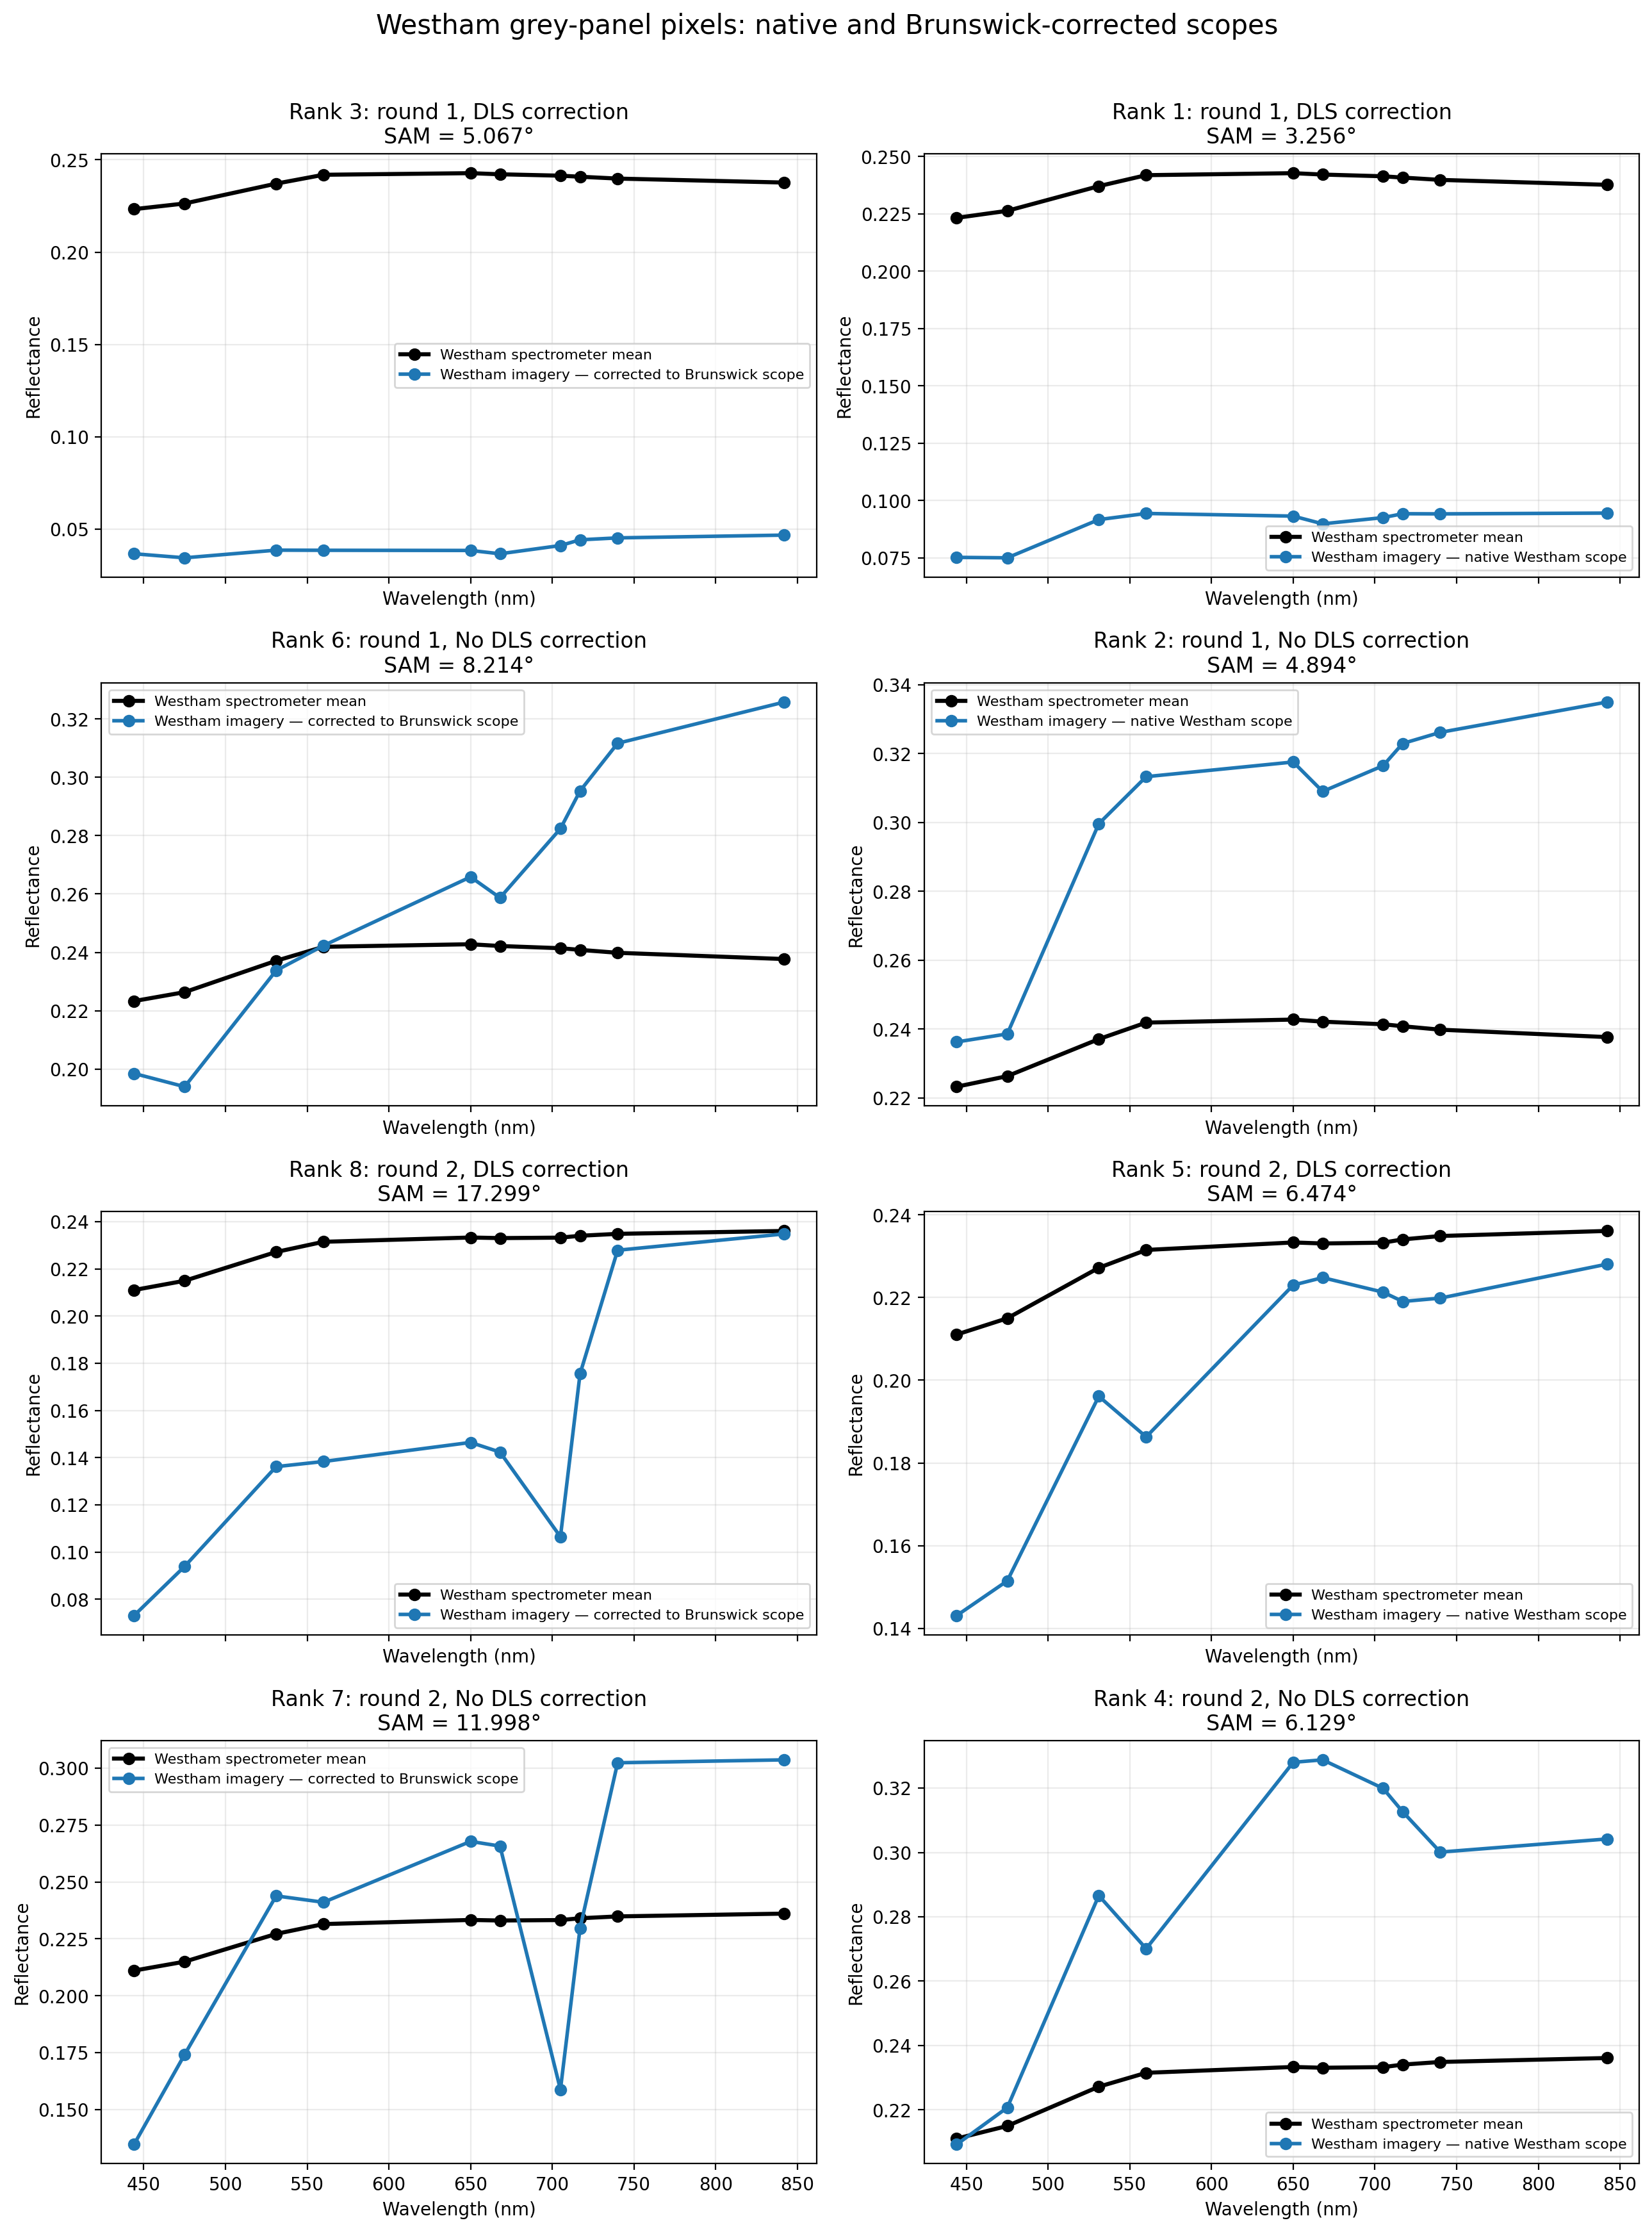

In [24]:
def plot_grey_panel_spectra(
    comparison: pd.DataFrame,
    ranking: pd.DataFrame,
) -> None:
    n = len(comparison)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 4.3 * nrows),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    rank_lookup = ranking.set_index(
        ["round", "dls_mode", "comparison_scope"]
    )["rank"].to_dict()

    for ax, (_, row) in zip(axes, comparison.iterrows()):
        image = row[
            [f"{band}_image" for band in SPECTRAL_COLUMNS]
        ].to_numpy(dtype=float)
        ground = row[
            [f"{band}_ground" for band in SPECTRAL_COLUMNS]
        ].to_numpy(dtype=float)

        angle = spectral_angle_degrees(image, ground)
        key = (
            int(row["round"]),
            row["dls_mode"],
            row["comparison_scope"],
        )
        rank = rank_lookup.get(key, np.nan)

        ax.plot(
            SPECTRAL_COLUMNS,
            ground,
            marker="o",
            linewidth=2.3,
            color="black",
            label=(
                f"{row['ground_truth_site'].title()} "
                "spectrometer mean"
            ),
        )
        ax.plot(
            SPECTRAL_COLUMNS,
            image,
            marker="o",
            linewidth=2.0,
            label=row["scope_label"],
        )
        ax.set_title(
            f"Rank {rank}: round {int(row['round'])}, "
            f"{DLS_DISPLAY_LABELS[row['dls_mode']]}\n"
            f"SAM = {angle:.3f}°"
        )
        ax.set_ylabel("Reflectance")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    for ax in axes[n:]:
        ax.set_visible(False)

    for ax in axes:
        if ax.get_visible():
            ax.set_xlabel("Wavelength (nm)")

    fig.suptitle(
        "Westham grey-panel pixels: native and Brunswick-corrected scopes",
        y=1.01,
        fontsize=15,
    )
    fig.tight_layout()
    plt.show()


plot_grey_panel_spectra(grey_comparison, grey_ranking)

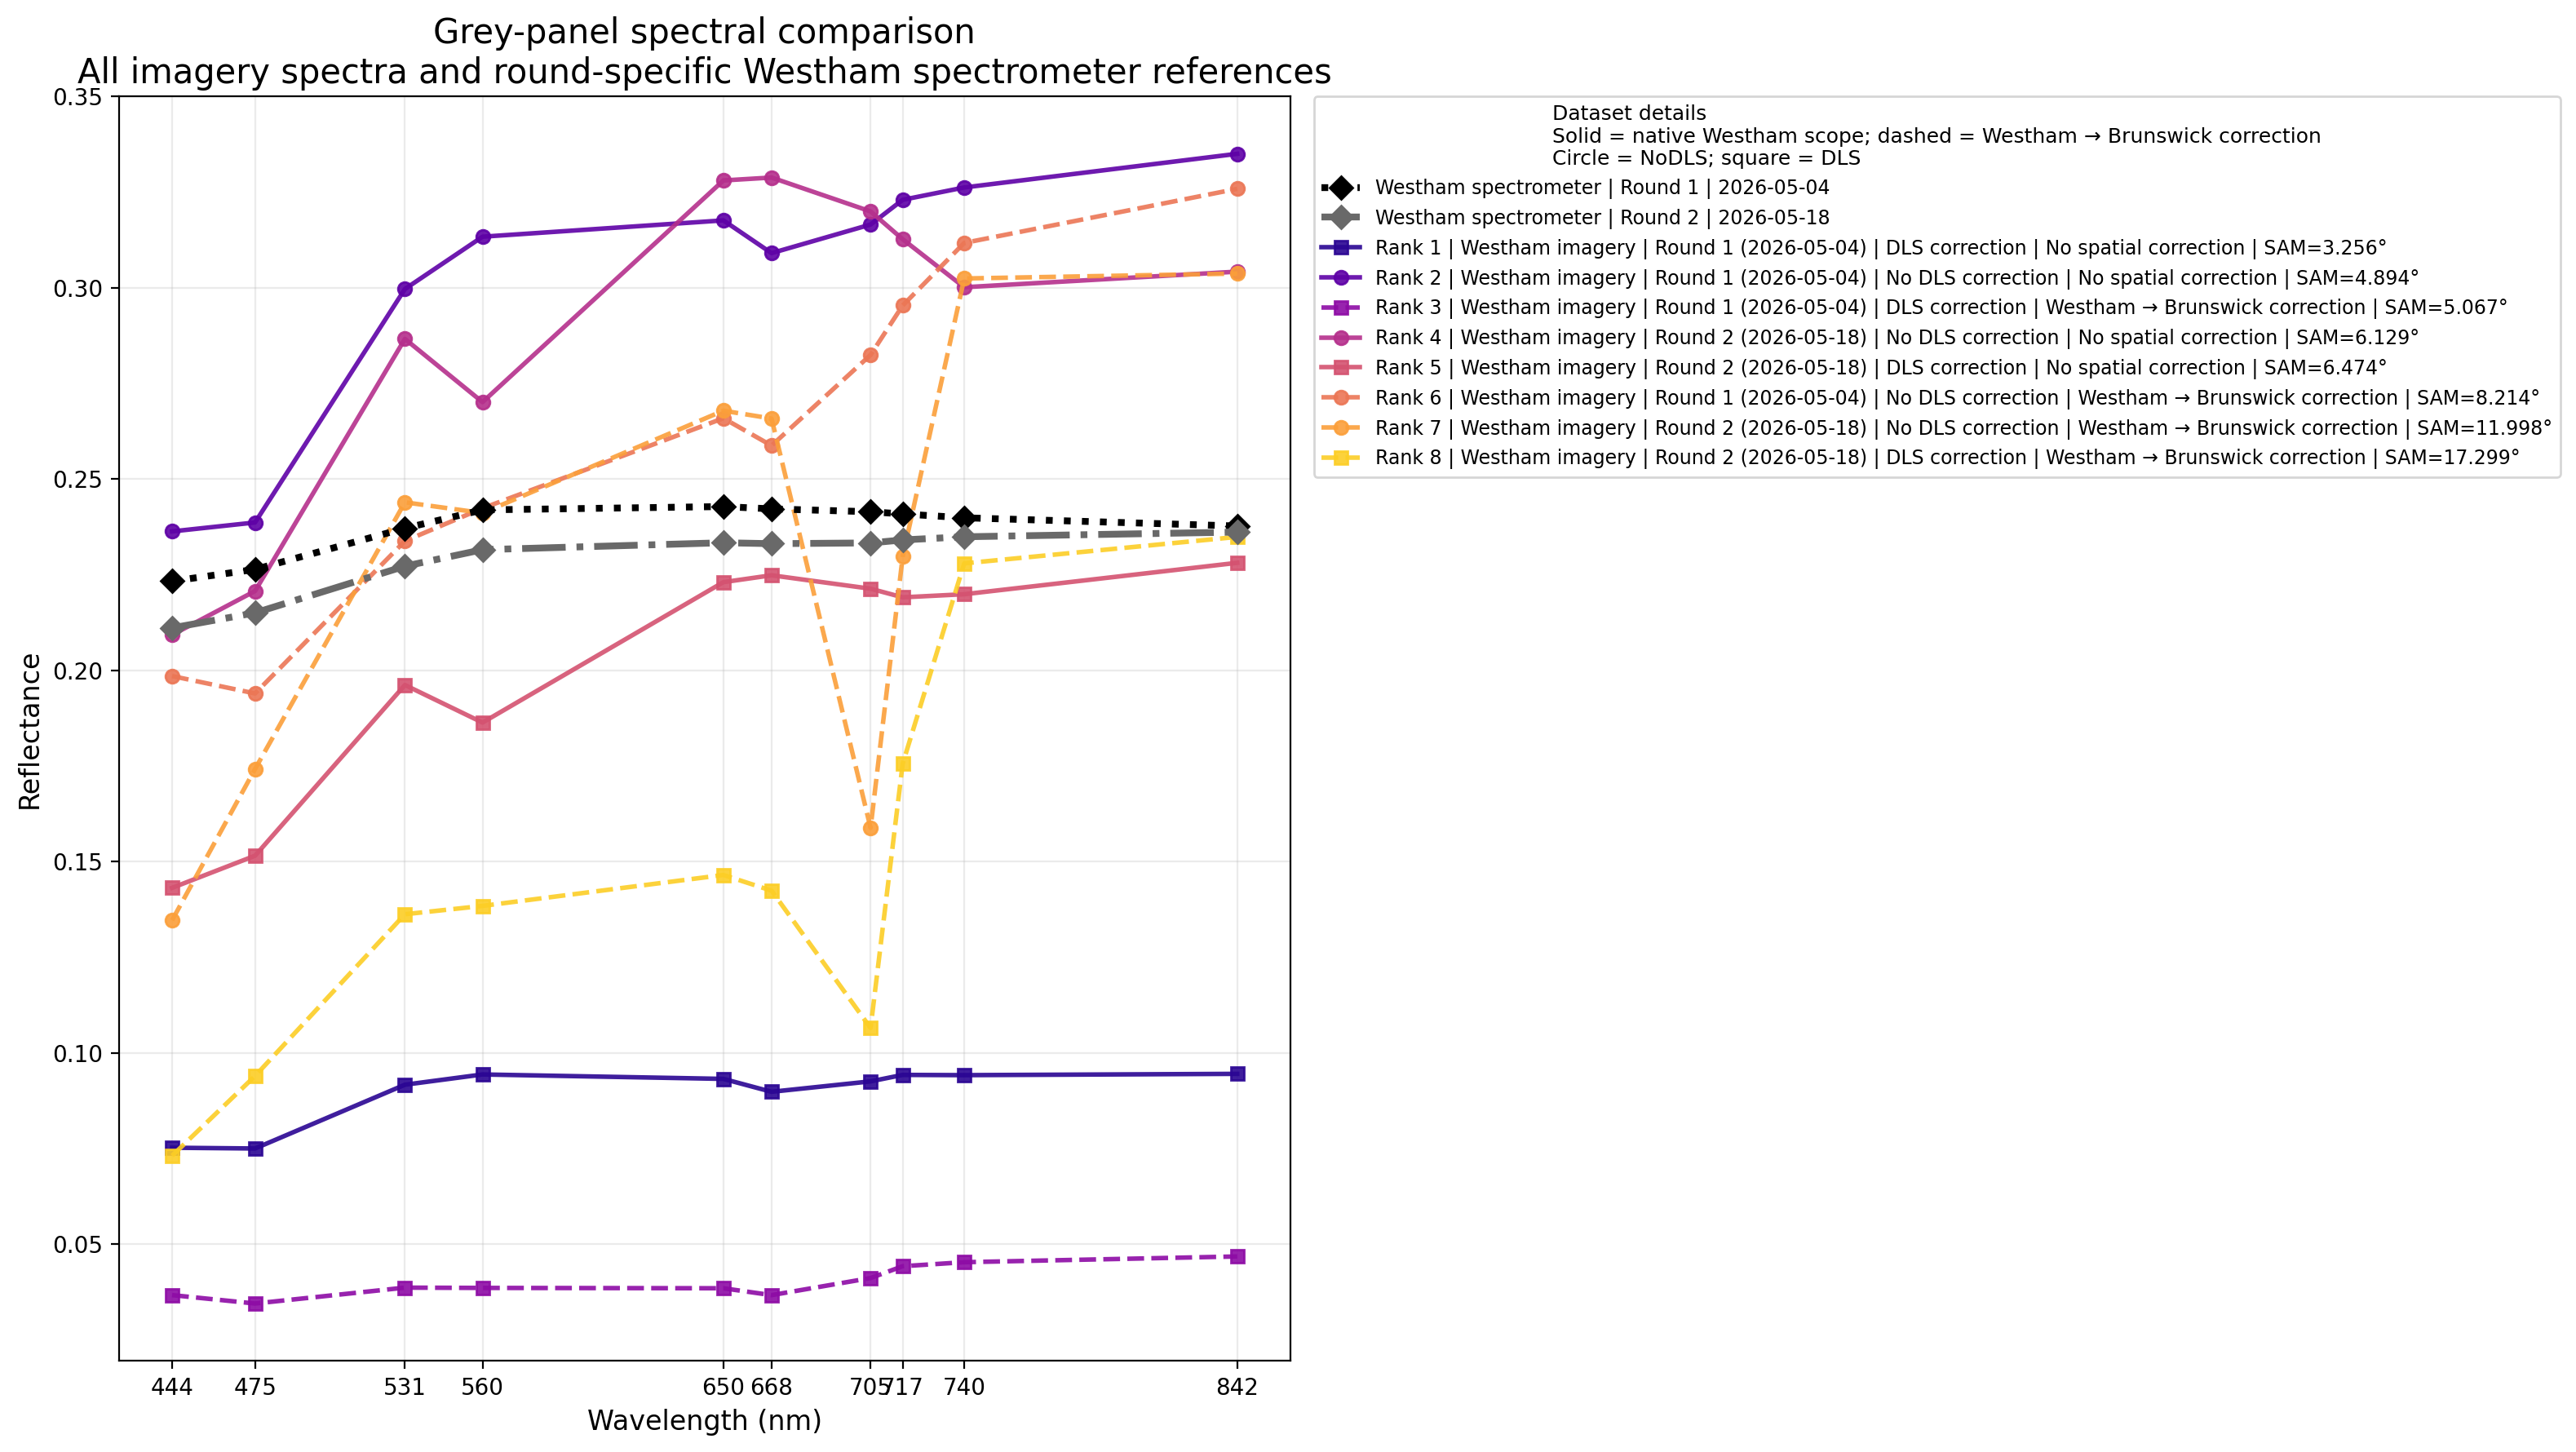

In [27]:
# ============================================================
# All grey-panel spectra in one figure
# ============================================================

plot_spectra = grey_comparison.merge(
    grey_ranking[
        [
            "round",
            "dls_mode",
            "comparison_scope",
            "rank",
            "spectral_angle_deg",
        ]
    ],
    on=["round", "dls_mode", "comparison_scope"],
    how="left",
    validate="one_to_one",
)

plot_spectra = plot_spectra.sort_values("rank").reset_index(drop=True)

# Visual conventions
scope_linestyles = {
    "westham_native": "-",
    "brunswick_corrected": "--",
}

scope_names = {
    "westham_native": "No spatial correction",
    "brunswick_corrected": "Westham → Brunswick correction",
}

dls_markers = {
    "NoDLS": "o",
    "DLS": "s",
}

ground_colours = {
    1: "black",
    2: "dimgray",
}

ground_linestyles = {
    1: ":",
    2: "-.",
}

# Colour imagery spectra by SAM rank.
n_ranks = len(plot_spectra)
rank_colours = plt.cm.plasma(
    np.linspace(0.05, 0.90, max(n_ranks, 2))
)

fig, ax = plt.subplots(figsize=(16, 9))

# ------------------------------------------------------------
# Plot each round-specific Westham spectrometer spectrum once.
# Both native and corrected imagery scopes use this reference.
# ------------------------------------------------------------
for round_number in sorted(plot_spectra["round"].unique()):
    round_rows = plot_spectra.loc[
        plot_spectra["round"].eq(round_number)
    ]

    reference = round_rows.iloc[0][
        [f"{band}_ground" for band in SPECTRAL_COLUMNS]
    ].to_numpy(dtype=float)

    date = ROUND_DATES[int(round_number)]

    ax.plot(
        SPECTRAL_COLUMNS,
        reference,
        color=ground_colours[int(round_number)],
        linestyle=ground_linestyles[int(round_number)],
        marker="D",
        linewidth=3.0,
        markersize=7,
        label=(
            f"Westham spectrometer | "
            f"Round {int(round_number)} | {date}"
        ),
        zorder=4,
    )

# ------------------------------------------------------------
# Plot every tested imagery spectrum.
# ------------------------------------------------------------
for colour_index, (_, row) in enumerate(plot_spectra.iterrows()):
    image_spectrum = row[
        [f"{band}_image" for band in SPECTRAL_COLUMNS]
    ].to_numpy(dtype=float)

    rank = int(row["rank"])
    round_number = int(row["round"])
    date = ROUND_DATES[round_number]
    dls_mode = row["dls_mode"]
    comparison_scope = row["comparison_scope"]
    correction = scope_names[comparison_scope]
    sam = row["spectral_angle_deg"]

    label = (
        f"Rank {rank} | Westham imagery | "
        f"Round {round_number} ({date}) | "
        f"{DLS_DISPLAY_LABELS[dls_mode]} | "
        f"{correction} | SAM={sam:.3f}°"
    )

    ax.plot(
        SPECTRAL_COLUMNS,
        image_spectrum,
        color=rank_colours[colour_index],
        linestyle=scope_linestyles[comparison_scope],
        marker=dls_markers[dls_mode],
        linewidth=2.0,
        markersize=6,
        alpha=0.90,
        label=label,
        zorder=2,
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_title(
    "Grey-panel spectral comparison\n"
    "All imagery spectra and round-specific Westham spectrometer references",
    fontsize=15,
)

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Reflectance", fontsize=12)

ax.set_xticks(SPECTRAL_COLUMNS)
ax.grid(alpha=0.25)

# Put the detailed legend outside the axes.
ax.legend(
    title=(
        "Dataset details\n"
        "Solid = native Westham scope; "
        "dashed = Westham → Brunswick correction\n"
        "Circle = NoDLS; square = DLS"
    ),
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
    fontsize=8.5,
    title_fontsize=9,
)

fig.tight_layout()
plt.show()

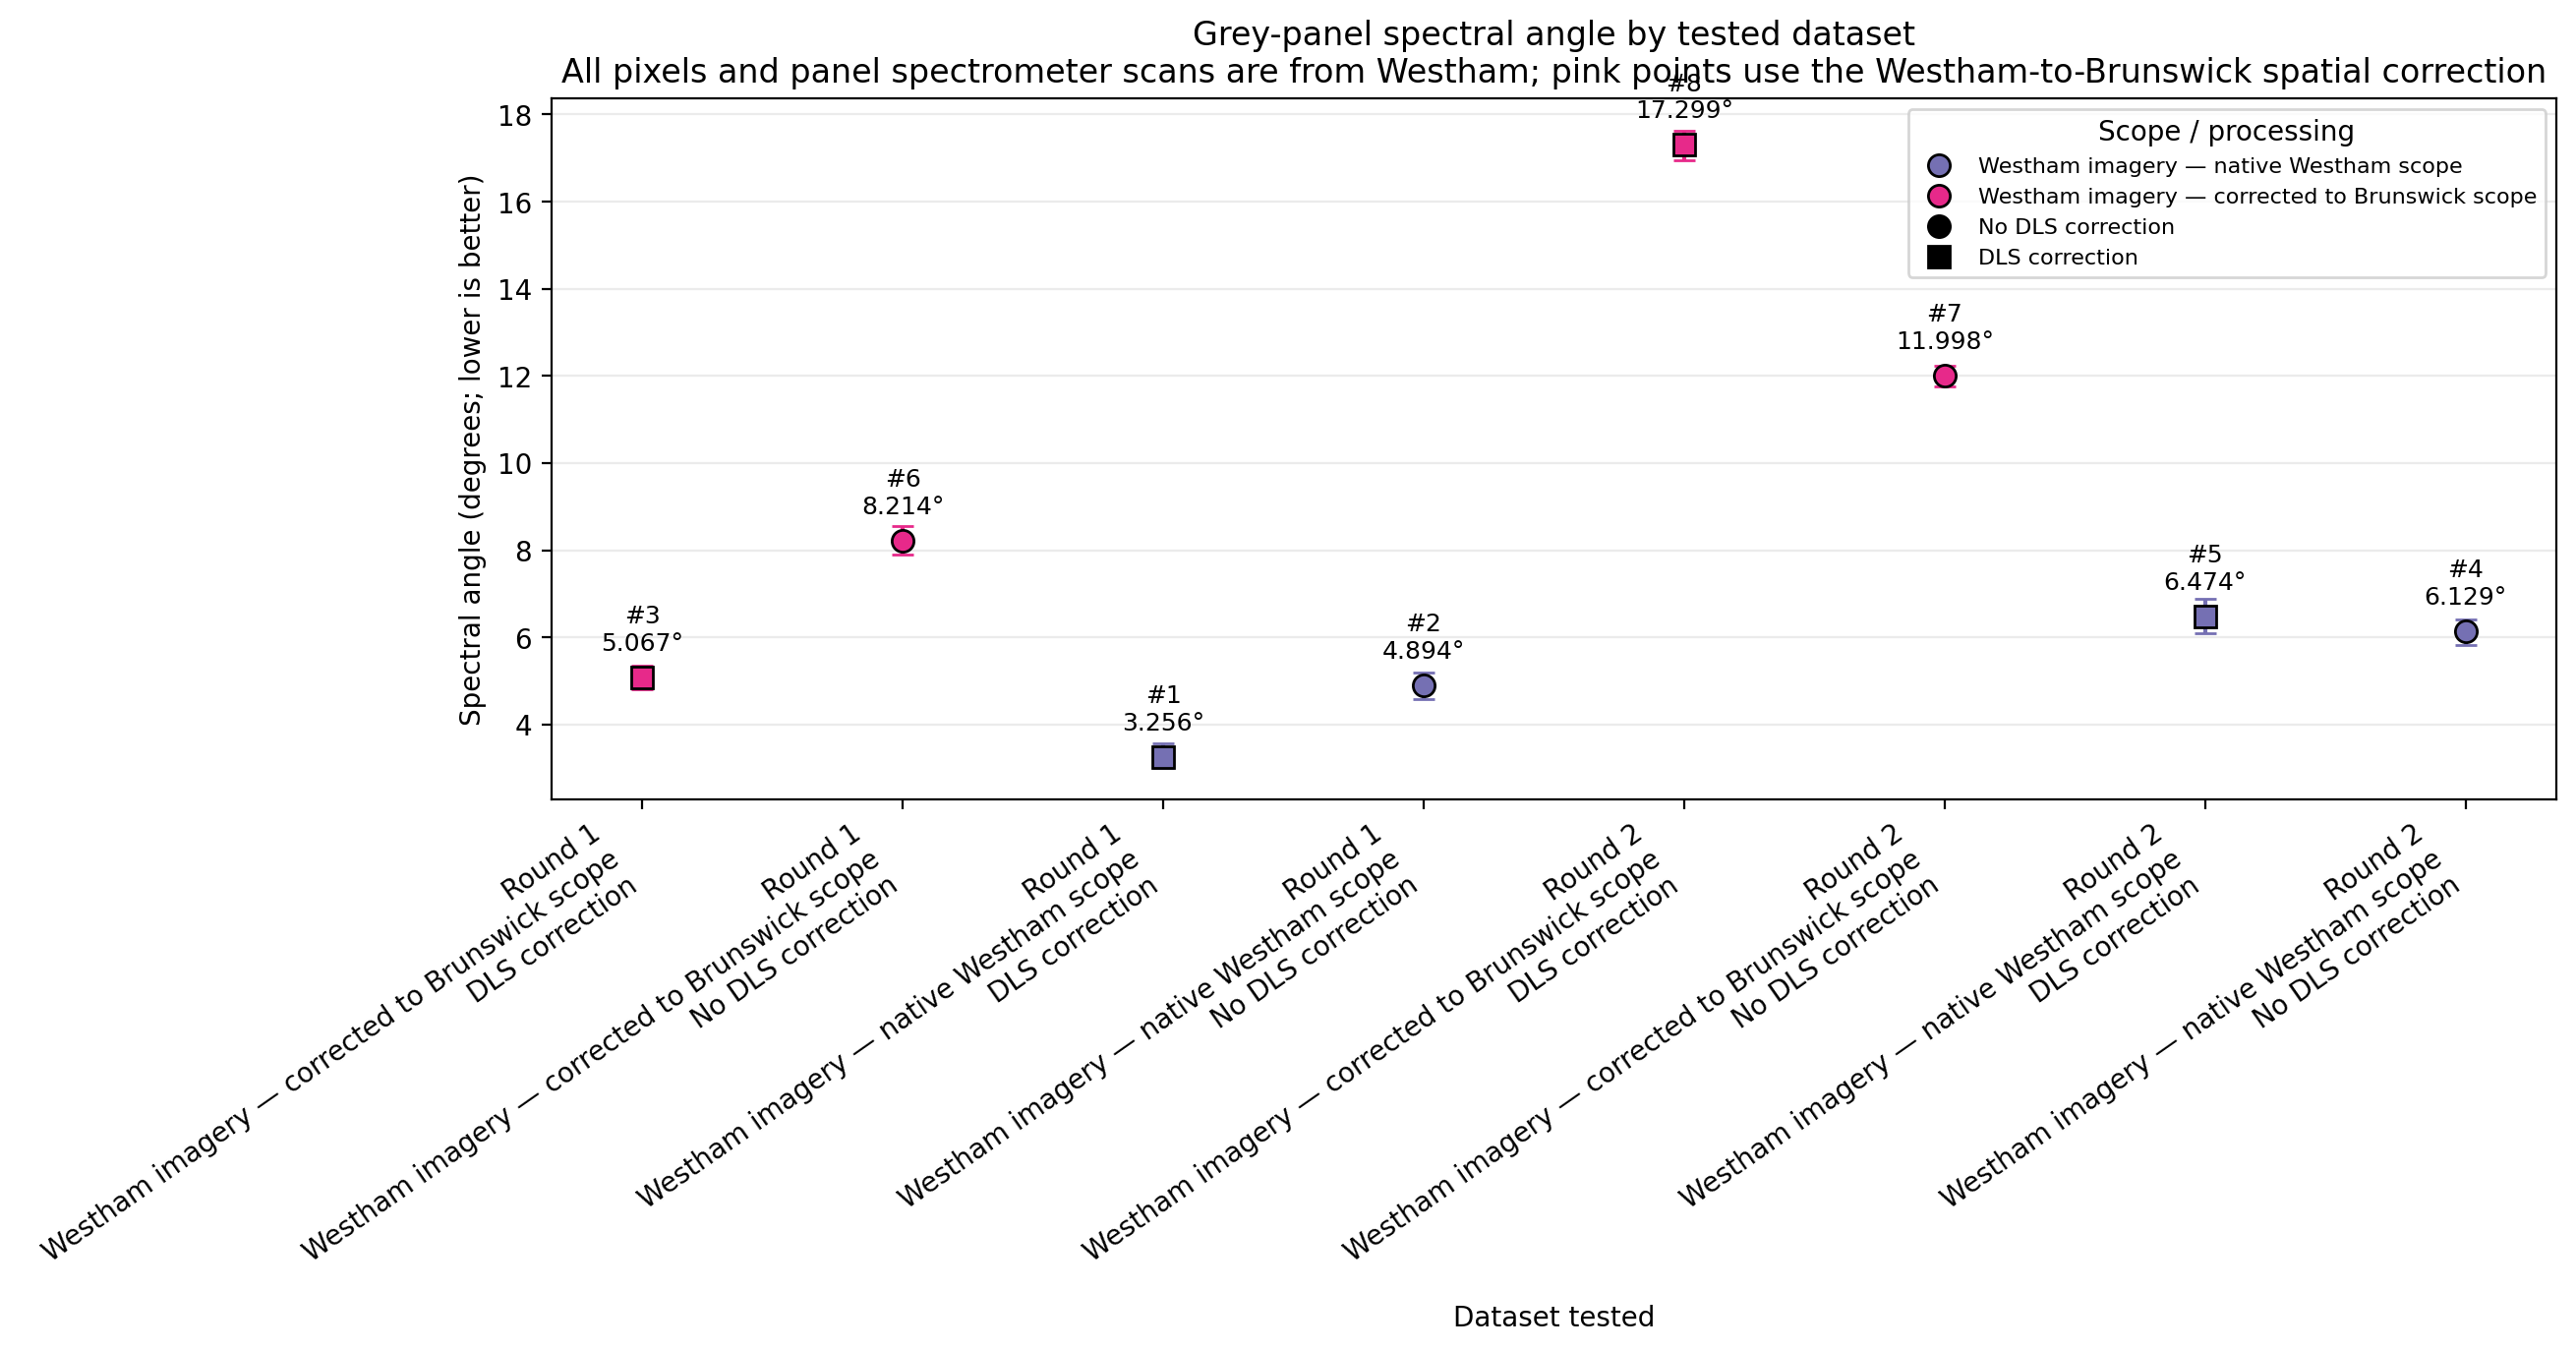

In [25]:
plot_data = grey_ranking.merge(
    grey_sam_bootstrap,
    on=[
        "round",
        "date",
        "dls_mode",
        "comparison_scope",
        "scope_label",
        "source_imagery_site",
        "ground_truth_site",
    ],
    how="left",
    suffixes=("", "_bootstrap"),
)

plot_data = plot_data.sort_values(
    ["round", "comparison_scope", "dls_mode"]
).reset_index(drop=True)

plot_data["dataset_tested"] = (
    "Round "
    + plot_data["round"].astype(str)
    + "\n"
    + plot_data["scope_label"]
    + "\n"
    + plot_data["dls_mode"].map(DLS_DISPLAY_LABELS)
)

scope_colour_map = {
    "westham_native": "#7570b3",
    "brunswick_corrected": "#e7298a",
}
marker_map = {
    "NoDLS": "o",
    "DLS": "s",
}

lower = (
    plot_data["spectral_angle_deg"]
    - plot_data["sam_ci_2.5_deg"]
).clip(lower=0)
upper = (
    plot_data["sam_ci_97.5_deg"]
    - plot_data["spectral_angle_deg"]
).clip(lower=0)

fig, ax = plt.subplots(
    figsize=(max(13, 1.65 * len(plot_data)), 7)
)
x = np.arange(len(plot_data))

for position, (_, row) in zip(x, plot_data.iterrows()):
    lower_error = (
        row["spectral_angle_deg"]
        - row["sam_ci_2.5_deg"]
    )
    upper_error = (
        row["sam_ci_97.5_deg"]
        - row["spectral_angle_deg"]
    )

    ax.errorbar(
        position,
        row["spectral_angle_deg"],
        yerr=np.array(
            [[max(0, lower_error)], [max(0, upper_error)]]
        ),
        fmt=marker_map[row["dls_mode"]],
        color=scope_colour_map[row["comparison_scope"]],
        markeredgecolor="black",
        markersize=8,
        capsize=4,
        zorder=2,
    )
    ax.annotate(
        f"#{int(row['rank'])}\n"
        f"{row['spectral_angle_deg']:.3f}°",
        (position, row["spectral_angle_deg"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["dataset_tested"],
    rotation=35,
    ha="right",
)
ax.set_ylabel("Spectral angle (degrees; lower is better)")
ax.set_xlabel("Dataset tested")
ax.set_title(
    "Grey-panel spectral angle by tested dataset\n"
    "All pixels and panel spectrometer scans are from Westham; "
    "pink points use the Westham-to-Brunswick spatial correction"
)
ax.grid(axis="y", alpha=0.25)

scope_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=colour,
        markeredgecolor="black",
        label=SCOPE_LABELS[scope],
        markersize=8,
    )
    for scope, colour in scope_colour_map.items()
]
mode_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        color="black",
        linestyle="none",
        label=DLS_DISPLAY_LABELS[mode],
        markersize=8,
    )
    for mode, marker in marker_map.items()
]
ax.legend(
    handles=scope_handles + mode_handles,
    title="Scope / processing",
    fontsize=8,
)

plt.tight_layout()
plt.show()

## 14. Export compact result tables

In [26]:
OUTPUT_FOLDER = Path(
    "data/processed/imagery/radiometry_eval"
)
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

grey_ranking.to_csv(
    OUTPUT_FOLDER
    / "grey_panel_westham_source_spectral_angle_ranking.csv",
    index=False,
)
grey_scope_summary.to_csv(
    OUTPUT_FOLDER
    / "grey_panel_scope_and_dls_summary.csv",
    index=False,
)
grey_sam_bootstrap.to_csv(
    OUTPUT_FOLDER
    / "grey_panel_scope_sam_bootstrap.csv",
    index=False,
)
grey_match_audit.to_csv(
    OUTPUT_FOLDER
    / "grey_panel_scope_matching_audit.csv",
    index=False,
)
station_metrics.to_csv(
    OUTPUT_FOLDER
    / "station_spectral_and_ndvi_metrics.csv",
    index=False,
)

print("Saved result tables to:", OUTPUT_FOLDER.resolve())

Saved result tables to: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/notebooks/analysis/data/processed/imagery/radiometry_eval


## 15. Reporting guidance

The audit table should first confirm:

- every source image is Westham imagery;
- every panel spectrometer reference is Westham;
- round 1 uses Westham round-1 grey-panel scans;
- round 2 uses Westham round-2 grey-panel scans;
- corrected-scope rows use the date-, DLS-mode-, and band-specific
  `westham_to_brunswick` coefficients.

`brunswick_corrected` refers only to the corrected radiometric scope. It does
not indicate a Brunswick spectrometer or a Brunswick source image.

Rank individual datasets by `spectral_angle_deg`, with lower values indicating
better spectral-shape agreement. Report RMSE, bias, and gain-adjusted RMSE
alongside SAM.
